# Medin Categorization Task — Real-Time LLM/VLM Simulation

This notebook simulates the Levering (2020) categorization task in **real time**, treating LLMs and VLMs as active participants.

**Two conditions (confirmed against Psych-101 dataset):**
- **NLS** (`exp1.csv`): categories Z/W; exception items `212`, `121` contradict shape rule
- **LS** (`exp2.csv`): categories R/H; majority-of-digits rule (≥2 ones → R, ≥2 twos → H)

**Pipelines:** Text (LLMs) and Visual (VLMs). Includes block-level learning curves, exception item tracking, N_RUNS averaging with SE, human benchmarks from Levering et al. (2020), and counterbalancing to correct token-level response bias.

### Imports & API Client

In [80]:
from openai import OpenAI
from tqdm import tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
import re, io, base64, os
from dotenv import load_dotenv

In [81]:
load_dotenv()

client = OpenAI(
    api_key=os.getenv("OPENAI_API_KEY"),
    base_url="https://litellm.ccv.brown.edu"
)

### Task Constants

Stimulus encoding: `XYZ` where
- **X** — shape: `1`=square, `2`=triangle
- **Y** — size: `1`=1.50 inch (large), `2`=0.75 inch (small)
- **Z** — shading: `1`=black, `2`=white

**NLS category structure** (exp1): Z={111,122,212}, W={121,211,222}. Exception items (contradict shape rule): `212`, `121`.

**LS category structure** (exp2): R={111,112,211}, H={122,221,222}. Majority-of-digits rule: ≥2 ones → R, ≥2 twos → H. Verified computationally.

In [82]:
# ── Quick-test flag ───────────────────────────────────────────────────────
QUICK_TEST = False   # True: N_RUNS=1, N_REPS=3, first model only, no visual
                    # False: full production run

# ── Diagnostic flags (forced off in QUICK_TEST) ────────────────────────────
RELABELED     = True   # surface relabeling diagnostic (Llama NLS only)
COUNTERBALANCE = True   # averaging across swapped/standard labels cancels
                        # token-level response bias toward any single label

if QUICK_TEST:
    COUNTERBALANCE = True
    RELABELED      = True

# ── Category structures ────────────────────────────────────────────────────
# NLS: Non-linearly separable — Z/W; no single dimension predicts category
TRUE_CATEGORIES_NLS = {
    "111": "Z", "122": "Z", "212": "Z",
    "121": "W", "211": "W", "222": "W",
}
# LS: Linearly separable — R/H; majority-of-digits rule verified:
#   >=2 ones -> R, >=2 twos -> H. Confirmed against exp2 stimulus set.
TRUE_CATEGORIES_LS = {
    "111": "R", "112": "R", "122": "H",
    "211": "R", "221": "H", "222": "H",
}

# ── Test categories — covers all 8 stimuli for evaluation purposes ────────
# Extends training assignments to stimuli not seen during training.
# Used only for test block correctness evaluation, not for feedback during training.

def _majority_cat(code, cat_one, cat_two):
    """Assign category by majority digit: more 1s -> cat_one, more 2s -> cat_two."""
    return cat_one if code.count('1') > code.count('2') else cat_two

# LS: majority-of-digits rule applies cleanly to all 8 stimuli
TEST_CATEGORIES_LS = {
    code: _majority_cat(code, 'R', 'H')
    for code in ['111', '112', '121', '122', '211', '212', '221', '222']
}

# NLS: use training assignments where defined, extend to missing stimuli
# Missing stimuli from NLS training are 112 and 221
TEST_CATEGORIES_NLS = dict(TRUE_CATEGORIES_NLS)
_NLS_EXTENSIONS = {'112': 'W', '221': 'Z'}
TEST_CATEGORIES_NLS.update(_NLS_EXTENSIONS)

# Sanity check — print any conflicts between training and test categories
_conflicts = []
for code, cat in TRUE_CATEGORIES_NLS.items():
    if TEST_CATEGORIES_NLS.get(code) != cat:
        _conflicts.append(f'{code}: train={cat} test={TEST_CATEGORIES_NLS[code]}')
for code, cat in TRUE_CATEGORIES_LS.items():
    if TEST_CATEGORIES_LS.get(code) != cat:
        _conflicts.append(f'{code}: train={cat} test={TEST_CATEGORIES_LS[code]}')
if _conflicts:
    print('WARNING — test/train category conflicts:', _conflicts)
else:
    print('TEST_CATEGORIES verified — no conflicts with training assignments')
    print('TEST_CATEGORIES_NLS:', TEST_CATEGORIES_NLS)
    print('TEST_CATEGORIES_LS:',  TEST_CATEGORIES_LS)

TEST_CATEGORIES_MAP = {'NLS': TEST_CATEGORIES_NLS, 'LS': TEST_CATEGORIES_LS}

CONDITIONS = {"NLS": TRUE_CATEGORIES_NLS, "LS": TRUE_CATEGORIES_LS}

# NLS and LS use different training stimulus sets
TRAIN_STIMULI_NLS = ["111", "122", "212", "121", "211", "222"]
TRAIN_STIMULI_LS  = ["111", "112", "122", "211", "221", "222"]
TRAIN_STIMULI_MAP = {"NLS": TRAIN_STIMULI_NLS, "LS": TRAIN_STIMULI_LS}

TEST_STIMULI = ["111", "112", "121", "122", "211", "212", "221", "222"]

CATEGORY_TOKENS_NLS = {"Z", "W"}
CATEGORY_TOKENS_LS  = {"R", "H"}
CATEGORY_TOKENS_MAP = {"NLS": CATEGORY_TOKENS_NLS, "LS": CATEGORY_TOKENS_LS}

RATING_TOKENS = {str(i) for i in range(1, 10)}

# Exception items for NLS: contradict the shape-only heuristic (digit0==1->Z, ==2->W)
EXCEPTION_ITEMS_NLS = ["212", "121"]
EXCEPTION_ITEMS_MAP = {"NLS": EXCEPTION_ITEMS_NLS, "LS": []}

# ── Training parameters ────────────────────────────────────────────────────
# Reduced from 25 to 10 blocks for API cost feasibility;
# covers the steepest part of the human learning curve.
N_REPS  = 3  if QUICK_TEST else 6
N_RUNS  = 1  if QUICK_TEST else 1
SEEDS   = [2,5,3]

# ── Models ─────────────────────────────────────────────────────────────────
_ALL_TEXT_MODELS   = ["gpt-5.2"]
_ALL_VISION_MODELS = ["gpt-5.2"]

TEXT_MODELS   = ["gpt-5.2"]                 if QUICK_TEST else _ALL_TEXT_MODELS
VISION_MODELS = ["gpt-5.2"]                  if QUICK_TEST else _ALL_VISION_MODELS

# ── Counterbalancing label maps ────────────────────────────────────────────
# Averaging across swapped and standard label assignments cancels token-level
# response bias toward any single label.
LABEL_MAPS_NLS = [
    {"Z": "Z", "W": "W"},   # standard
    {"Z": "W", "W": "Z"},   # labels swapped only
]
LABEL_MAPS_LS = [
    {"R": "R", "H": "H"},   # standard
    {"R": "H", "H": "R"},   # labels swapped only
]
LABEL_MAPS = {"NLS": LABEL_MAPS_NLS, "LS": LABEL_MAPS_LS}

# ── Instruction texts (per condition, category labels vary) ────────────────
def _make_instruction(cat_a, cat_b):
    return (
        "You will observe a series of objects, one at a time.\n"
        "The objects differ along three binary dimensions: shape (square vs. triangle), "
        "size (1.50 inch vs. 0.75 inch), and shading (black vs. white).\n"
        "Each dimension is indicated by the three digits, for example, '121' means a "
        "square, 0.75 inch, black object.\n"
        f"Based on some combination of the three dimensions, each object belongs to one "
        f"of two categories, {cat_a} or {cat_b}.\n"
        f"You have to assign each object to one of the two categories by pressing the "
        f"corresponding key.\n"
        "If your choice is correct, you get a point, otherwise you lose a point.\n"
        "Your goal is to get as many points as possible.\n"
        "At some point, you begin a 'test block' in which you will see eight objects.\n"
        "Here, you have to assign each object to one of the two categories as before.\n"
        "Furthermore, you have to rate how typical the object is for the category you "
        "chose, on a scale from 1 to 9.\n"
        "1 means 'not at all typical', and 9 means 'most typical'."
    )

def _make_visual_instruction(cat_a, cat_b):
    return (
        "You will observe a series of objects, one at a time.\n"
        "The objects differ along three binary dimensions: shape (square vs. triangle), "
        "size (large vs. small), and shading (black vs. white).\n"
        f"Each object belongs to one of two categories, {cat_a} or {cat_b}.\n"
        "You have to assign each object to one of the two categories by pressing the "
        "corresponding key.\n"
        "If your choice is correct, you get a point, otherwise you lose a point.\n"
        "Your goal is to get as many points as possible.\n"
        "At some point, you begin a 'test block' in which you will see eight objects.\n"
        "Here, you have to assign each object to one of the two categories as before.\n"
        "Furthermore, you have to rate how typical the object is for the category you "
        "chose, on a scale from 1 to 9.\n"
        "1 means 'not at all typical', and 9 means 'most typical'."
    )

INSTRUCTION_TEXT_NLS    = _make_instruction("Z", "W")
INSTRUCTION_TEXT_LS     = _make_instruction("R", "H")
VISUAL_INSTRUCTION_NLS  = _make_visual_instruction("Z", "W")
VISUAL_INSTRUCTION_LS   = _make_visual_instruction("R", "H")
INSTRUCTION_TEXTS       = {"NLS": INSTRUCTION_TEXT_NLS, "LS": INSTRUCTION_TEXT_LS}
VISUAL_INSTRUCTIONS     = {"NLS": VISUAL_INSTRUCTION_NLS, "LS": VISUAL_INSTRUCTION_LS}

# ── Human benchmarks from Levering et al. (2020) Figure 4 ─────────────────
HUMAN_NLS_BLOCKS    = [0.54, 0.62, 0.68, 0.73, 0.77, 0.80, 0.82, 0.83, 0.84, 0.85]
HUMAN_LS_BLOCKS     = [0.52, 0.57, 0.62, 0.66, 0.69, 0.71, 0.73, 0.74, 0.75, 0.76]
HUMAN_NLS_EXCEPTION = 0.755
HUMAN_NLS_NONEXCEPT = 0.832

# For backward-compat references used in older cells
TRUE_CATEGORIES = TRUE_CATEGORIES_NLS
TRAIN_STIMULI   = TRAIN_STIMULI_NLS

print(f"QUICK_TEST={QUICK_TEST} | COUNTERBALANCE={COUNTERBALANCE} | RELABELED={RELABELED}")
print(f"N_REPS={N_REPS} | N_RUNS={N_RUNS} | seeds={SEEDS}")
print(f"TEXT_MODELS={TEXT_MODELS}")
print(f"VISION_MODELS={VISION_MODELS}")

TEST_CATEGORIES verified — no conflicts with training assignments
TEST_CATEGORIES_NLS: {'111': 'Z', '122': 'Z', '212': 'Z', '121': 'W', '211': 'W', '222': 'W', '112': 'W', '221': 'Z'}
TEST_CATEGORIES_LS: {'111': 'R', '112': 'R', '121': 'R', '122': 'H', '211': 'R', '212': 'H', '221': 'H', '222': 'H'}
QUICK_TEST=False | COUNTERBALANCE=True | RELABELED=True
N_REPS=6 | N_RUNS=1 | seeds=[2, 5, 3]
TEXT_MODELS=['gpt-5.2']
VISION_MODELS=['gpt-5.2']


### Simulator & Helper Functions

In [83]:
class CategorizationSimulator:
    """Real-time simulator for the Levering (2020) categorization task."""

    def __init__(self, true_categories, train_stimuli, test_stimuli, n_reps=10, seed=42):
        self.true_categories = true_categories
        self.train_stimuli   = train_stimuli
        self.test_stimuli    = test_stimuli
        self.n_reps          = n_reps
        rng    = np.random.default_rng(seed)
        blocks = [rng.permutation(train_stimuli).tolist() for _ in range(n_reps)]
        self.train_sequence = [s for block in blocks for s in block]

    def feedback(self, stimulus, response):
        """Return (is_correct, points_str)."""
        correct = response.upper() == self.true_categories.get(stimulus, "")
        return correct, "1" if correct else "0"


def apply_label_map(text, label_map):
    """Single-pass substitution of original category labels -> shown labels."""
    if not label_map or all(k == v for k, v in label_map.items()):
        return text
    pattern = '|'.join(r'\b' + re.escape(k) + r'\b' for k in label_map)
    return re.sub(pattern, lambda m: label_map[m.group(0)], text)


def sample_from_logprobs(logprobs, valid_tokens):
    """Probabilistically sample a token from top-logprobs, restricted to valid_tokens."""
    valid = [e for e in logprobs if e.token.strip().upper() in valid_tokens]
    if not valid:
        return np.random.choice(sorted(valid_tokens))
    tokens = [e.token.strip().upper() for e in valid]
    log_p  = np.array([e.logprob for e in valid])
    probs  = np.exp(log_p); probs /= probs.sum()
    return np.random.choice(tokens, p=probs)


def parse_token(text, valid_tokens):
    """Extract first matching token from free-text response."""
    text = text.strip().upper()
    for t in sorted(valid_tokens):
        if t in text:
            return t
    return np.random.choice(sorted(valid_tokens))


def compute_block_curves(train_results, block_size, exception_items):
    """Compute per-block accuracy and exception/non-exception accuracy curves."""
    n_blocks = len(train_results) // block_size
    block_acc, exception_curve, non_exception_curve = [], [], []
    for b in range(n_blocks):
        trials = train_results[b * block_size:(b + 1) * block_size]
        block_acc.append(np.mean([r["correct"] for r in trials]))
        exc     = [r["correct"] for r in trials if r["stimulus"] in exception_items]
        non_exc = [r["correct"] for r in trials if r["stimulus"] not in exception_items]
        exception_curve.append(np.mean(exc)     if exc     else np.nan)
        non_exception_curve.append(np.mean(non_exc) if non_exc else np.nan)
    return block_acc, exception_curve, non_exception_curve

---
## Pipeline 1 — Text-Based Simulation

Each model sees stimuli as numeric codes (`211`, `112`, …) and accumulates the full trial history in its context, exactly as in the Psych-101 format.  
Where the proxy supports log-probabilities, we **sample** the model's response from its output distribution (stochastic, like a human); otherwise we take the greedy top token.

In [84]:
def run_text_simulation(model, simulator, instruction_text, category_tokens,
                        condition, label_map=None, permute_digits=False,
                        exception_items=None, test_categories=None):
    """Run one complete text-based simulation for a single model.

    Args:
        label_map:       dict mapping original label -> shown label (e.g. {"Z":"W","W":"Z"})
        permute_digits:  if True, swap digit positions 0 and 2 in stimulus codes shown to model
        exception_items: list of stimulus codes to track separately in block curves
        test_categories: dict mapping all 8 test stimuli -> true category (for novel items).
                         Falls back to simulator.true_categories if None.
    """
    if label_map is None:
        label_map = {t: t for t in category_tokens}
    if exception_items is None:
        exception_items = []

    inverse_map        = {v: k for k, v in label_map.items()}
    shown_cat_tokens   = {label_map[t] for t in category_tokens}
    token_cue          = ' or '.join(sorted(shown_cat_tokens))
    inst               = apply_label_map(instruction_text, label_map)

    def shown_code(code):
        return code[2] + code[1] + code[0] if permute_digits else code

    def query(prompt, valid_tokens):
        resp = client.chat.completions.create(
            model=model,
            messages=[{"role": "user", "content": prompt}],
            logprobs=True,
            top_logprobs=5,
        )
        lp = resp.choices[0].logprobs
        if lp and lp.content:
            return sample_from_logprobs(lp.content[0].top_logprobs, valid_tokens)
        return parse_token(resp.choices[0].message.content, valid_tokens)

    # ── Training block ─────────────────────────────────────────────────────
    context      = inst
    train_results = []

    for trial_num, stimulus in enumerate(tqdm(simulator.train_sequence,
                                              desc=f"{model.split('-')[0]} [train]",
                                              leave=True)):
        s_shown      = shown_code(stimulus)
        prompt       = context + f"\nYou see the image {s_shown}, press [(Respond with only {token_cue})"
        choice_shown = query(prompt, shown_cat_tokens)
        choice_orig  = inverse_map.get(choice_shown, choice_shown)

        correct, pts = simulator.feedback(stimulus, choice_orig)
        context += f"\nYou see the image {s_shown}, press [{choice_shown}] and get {pts} points."

        train_results.append({
            "trial":        trial_num + 1,
            "stimulus":     stimulus,
            "choice":       choice_orig,
            "true_cat":     simulator.true_categories[stimulus],
            "correct":      correct,
            "is_exception": stimulus in exception_items,
        })

    # ── Test block ──────────────────────────────────────────────────────────
    context += "\n\nTest block:"
    test_results = []

    for stimulus in tqdm(simulator.test_stimuli,
                         desc=f"{model.split('-')[0]} [test]",
                         leave=True):
        s_shown      = shown_code(stimulus)
        cat_prompt   = context + f"\nYou see the image {s_shown}, press [(Respond with only {token_cue})"
        choice_shown = query(cat_prompt, shown_cat_tokens)
        choice_orig  = inverse_map.get(choice_shown, choice_shown)

        typ_prompt = (context +
                      f"\nYou see the image {s_shown}, press [{choice_shown}] "
                      "and judged the typicality to be [(Respond with a single digit 1-9)")
        typ_shown = query(typ_prompt, RATING_TOKENS)
        context += (f"\nYou see the image {s_shown}, press [{choice_shown}] "
                    f"and judged the typicality to be [{typ_shown}].")

        _test_cats = test_categories if test_categories is not None else simulator.true_categories
        true_cat   = _test_cats.get(stimulus)
        is_correct = (choice_orig == true_cat) if true_cat is not None else None

        test_results.append({
            "stimulus":   stimulus,
            "choice":     choice_orig,
            "typicality": int(typ_shown) if typ_shown and typ_shown.isdigit() else None,
            "true_cat":   true_cat or "?",
            "correct":    is_correct,
            "is_novel":   stimulus not in simulator.train_stimuli,
        })

    block_acc, exc_curve, nonexc_curve = compute_block_curves(
        train_results, len(simulator.train_stimuli), exception_items
    )

    return {
        "model":               model,
        "train":               train_results,
        "test":                test_results,
        "block_acc":           block_acc,
        "exception_curve":     exc_curve,
        "non_exception_curve": nonexc_curve,
        "label_map":           label_map,
        "permute_digits":      permute_digits,
    }

In [85]:
# Run Pipeline 1 for both conditions, N_RUNS seeds, optionally counterbalanced
#
# text_results[cond][model] = {
#   "all_block_accs":      shape (n_total_runs, N_REPS)
#   "mean_block_acc":      shape (N_REPS,)
#   "se_block_acc":        shape (N_REPS,)
#   "mean_exception_curve":     shape (N_REPS,)
#   "mean_non_exception_curve": shape (N_REPS,)
#   "mean_train_acc":      float  (bias-corrected)
#   "raw_train_acc":       float  (standard label map only, first seed)
#   "runs":                list of individual run dicts
# }

text_results     = {}
relabel_results  = {}   # only populated when RELABELED=True

for cond_name, cond_cats in CONDITIONS.items():
    text_results[cond_name] = {}
    train_stim  = TRAIN_STIMULI_MAP[cond_name]
    cat_tokens  = CATEGORY_TOKENS_MAP[cond_name]
    inst_text   = INSTRUCTION_TEXTS[cond_name]
    exc_items   = EXCEPTION_ITEMS_MAP[cond_name]
    maps        = LABEL_MAPS[cond_name]
    maps_to_use = maps if COUNTERBALANCE else [maps[0]]

    print(f"\n{'#'*60}")
    print(f"# CONDITION: {cond_name}  |  maps: {len(maps_to_use)}  |  runs: {N_RUNS}")
    print(f"{'#'*60}")

    for model in TEXT_MODELS:
        all_block_accs, all_exc, all_nonexc = [], [], []
        raw_train_acc  = None
        runs_log       = []

        for seed_i, seed in enumerate(SEEDS):
            simulator = CategorizationSimulator(
                cond_cats, train_stim, TEST_STIMULI, n_reps=N_REPS, seed=seed
            )
            for lmap in maps_to_use:
                is_standard = all(lmap[k] == k for k in lmap)
                lmap_label  = "standard" if is_standard else "swapped"
                print(f"  {model.split('-')[0]} | seed={seed} | map={lmap_label}")
                res = run_text_simulation(
                    model, simulator, inst_text, cat_tokens,
                    cond_name, label_map=lmap, exception_items=exc_items,
                    test_categories=TEST_CATEGORIES_MAP[cond_name]
                )
                all_block_accs.append(res["block_acc"])
                all_exc.append(res["exception_curve"])
                all_nonexc.append(res["non_exception_curve"])
                tr_acc = np.mean([r["correct"] for r in res["train"]])
                print(f"    train_acc={tr_acc:.1%}")
                if is_standard and raw_train_acc is None:
                    raw_train_acc = tr_acc
                runs_log.append({**res, "seed": seed, "lmap_label": lmap_label})

        arr = np.array(all_block_accs, dtype=float)
        text_results[cond_name][model] = {
            "all_block_accs":           arr,
            "mean_block_acc":           np.nanmean(arr, axis=0),
            "se_block_acc":             np.nanstd(arr, axis=0) / np.sqrt(len(arr)),
            "mean_exception_curve":     np.nanmean(all_exc, axis=0),
            "mean_non_exception_curve": np.nanmean(all_nonexc, axis=0),
            "mean_train_acc":           float(np.nanmean(arr)),
            "raw_train_acc":            raw_train_acc,
            "runs":                     runs_log,
        }
        # Flag potential token bias
        corrected = float(np.nanmean(arr))
        if raw_train_acc is not None and abs(corrected - raw_train_acc) > 0.05:
            print(f"  ⚠ Token bias flag: raw={raw_train_acc:.1%} corrected={corrected:.1%} "
                  f"(diff > 5pp) for {model} [{cond_name}]")

        # ── Relabeled diagnostics (Llama NLS only) ─────────────────────────
        if RELABELED and cond_name == "NLS" and model == "Llama-3.3-70B-Instruct":
            relabel_results.setdefault(cond_name, {}).setdefault(model, {})
            for variant_name, lmap_r, perm in [
                ("label_only",      {"Z": "P", "W": "Q"}, False),
                ("surface_relabel", {"Z": "P", "W": "Q"}, True),
            ]:
                print(f"  [relabeled] {variant_name}")
                sim_r = CategorizationSimulator(
                    cond_cats, train_stim, TEST_STIMULI, n_reps=N_REPS, seed=SEEDS[0]
                )
                res_r = run_text_simulation(
                    model, sim_r, inst_text, cat_tokens,
                    cond_name, label_map=lmap_r, permute_digits=perm,
                    exception_items=exc_items,
                    test_categories=TEST_CATEGORIES_MAP[cond_name]
                )
                relabel_results[cond_name][model][variant_name] = res_r
                print(f"    train_acc={np.mean([r['correct'] for r in res_r['train']]):.1%}")

print("\nDone.")


############################################################
# CONDITION: NLS  |  maps: 2  |  runs: 1
############################################################
  gpt | seed=2 | map=standard


gpt [test]: 100%|██████████| 8/8 [00:19<00:00,  2.45s/it]


    train_acc=94.4%
  gpt | seed=2 | map=swapped


gpt [test]: 100%|██████████| 8/8 [00:20<00:00,  2.60s/it]


    train_acc=88.9%
  gpt | seed=5 | map=standard


...

gpt [test]: 100%|██████████| 8/8 [00:20<00:00,  2.52s/it]


    train_acc=94.4%
  gpt | seed=3 | map=swapped


gpt [test]: 100%|██████████| 8/8 [00:18<00:00,  2.35s/it]

    train_acc=88.9%

Done.



/var/folders/6b/k7k7f9q56j1fy7v94985x3tc0000gn/T/ipykernel_41821/3517710462.py:62: RuntimeWarning: Mean of empty slice
  "mean_exception_curve":     np.nanmean(all_exc, axis=0),


### Pipeline 1 — Results

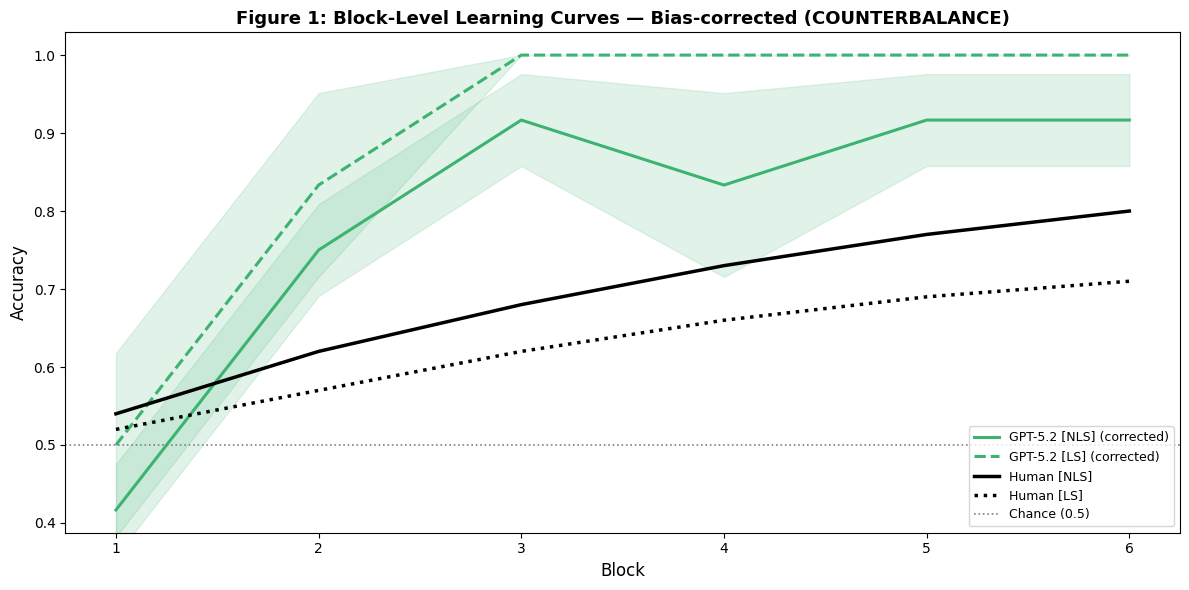

In [21]:
MODEL_COLORS = {
    "Llama-3.3-70B-Instruct": "mediumpurple",
    "gemini-3-flash-preview":  "coral",
    "gemini-2.5-pro":          "steelblue",
    "claude-sonnet-4-5":       "teal",
    "gpt-5.2":                 "mediumseagreen",
}

MODEL_DISPLAY = {
    "claude-sonnet-4-5":      "Claude Sonnet 4.5",
    "Llama-3.3-70B-Instruct": "Llama 3.3 70B",
    "gemini-3-flash-preview":  "Gemini 3 Flash",
    "gemini-2.5-pro":          "Gemini 2.5 Pro",
    "gpt-5.2":                "GPT-5.2",
}
fmt_model = lambda m: MODEL_DISPLAY.get(m, m)

COND_LS  = "--"
COND_NLS = "-"

BLOCKS = list(range(1, N_REPS + 1))

fig, ax = plt.subplots(figsize=(12, 6))

for cond_name, cond_res in text_results.items():
    ls = COND_NLS if cond_name == "NLS" else COND_LS
    for model, res in cond_res.items():
        color = MODEL_COLORS.get(model, "gray")
        mu    = res["mean_block_acc"]
        se    = res["se_block_acc"]
        n_total = res["all_block_accs"].shape[0]
        label = f"{fmt_model(model)} [{cond_name}]"
        if COUNTERBALANCE:
            label += " (corrected)"
        ax.plot(BLOCKS, mu, color=color, linestyle=ls, linewidth=2.2, label=label)
        ax.fill_between(BLOCKS, mu - se, mu + se, color=color, alpha=0.15)

# RELABELED variants (Llama NLS only)
if RELABELED and "NLS" in relabel_results:
    for model, variants in relabel_results["NLS"].items():
        for vname, res_r in variants.items():
            ba = res_r["block_acc"][:N_REPS]
            ax.plot(BLOCKS[:len(ba)], ba, color="mediumpurple",
                    linestyle=":", linewidth=1.5, alpha=0.7,
                    label=f"{fmt_model(model)} NLS [{vname}]")

# Human benchmarks (use first N_REPS blocks)
human_nls = HUMAN_NLS_BLOCKS[:N_REPS]
human_ls  = HUMAN_LS_BLOCKS[:N_REPS]
ax.plot(BLOCKS[:len(human_nls)], human_nls, color="black", linestyle="-",
        linewidth=2.5, label="Human [NLS]")
ax.plot(BLOCKS[:len(human_ls)],  human_ls,  color="black", linestyle=":",
        linewidth=2.5, label="Human [LS]")

ax.axhline(0.5, color="gray", linestyle=":", linewidth=1.2, label="Chance (0.5)")
ax.set_xlabel("Block", fontsize=12)
ax.set_ylabel("Accuracy", fontsize=12)
ax.set_xticks(BLOCKS)
ax.set_xticklabels([str(b) for b in BLOCKS])
_all_y1 = list(human_nls) + list(human_ls) + [0.5]
for _cr in text_results.values():
    for _r in _cr.values(): _all_y1.extend(_r['mean_block_acc'])
_lo1, _hi1 = min(_all_y1), max(_all_y1)
_pad1 = max(0.05 * (_hi1 - _lo1), 0.02)
ax.set_ylim(_lo1 - _pad1, _hi1 + _pad1)

bias_note = " — Bias-corrected (COUNTERBALANCE)" if COUNTERBALANCE else ""
ax.set_title("Figure 1: Block-Level Learning Curves" + bias_note, fontsize=13, fontweight="bold")
ax.legend(fontsize=9, ncol=1, loc="lower right")
plt.tight_layout()
plt.savefig("fig1_learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()

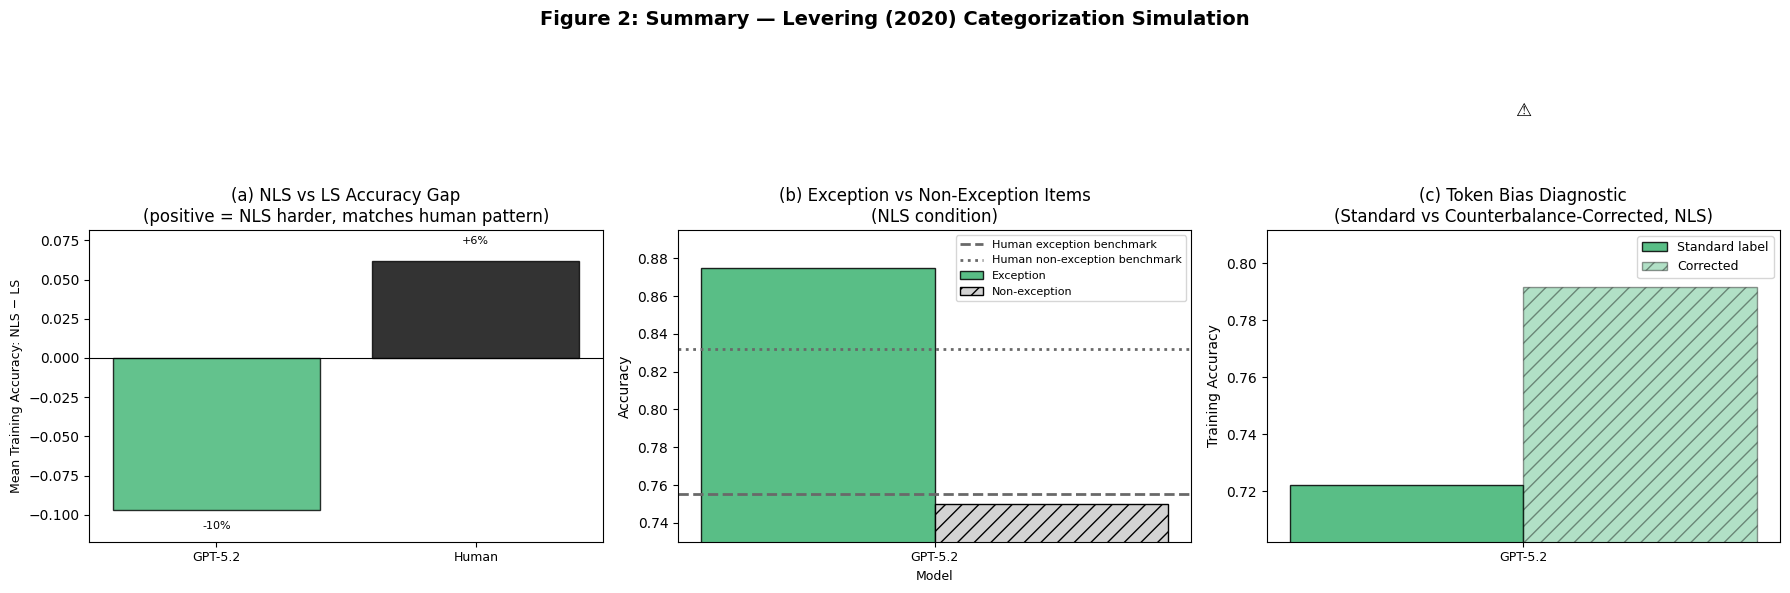

In [22]:
# ── Figure 2 — Three-panel summary ────────────────────────────────────────
MODEL_DISPLAY = {
    "claude-sonnet-4-5":      "Claude Sonnet 4.5",
    "Llama-3.3-70B-Instruct": "Llama 3.3 70B",
    "gemini-3-flash-preview":  "Gemini 3 Flash",
    "gemini-2.5-pro":          "Gemini 2.5 Pro",
    "gpt-5.2":                "GPT-5.2",
}
fmt_model = lambda m: MODEL_DISPLAY.get(m, m)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Figure 2: Summary — Levering (2020) Categorization Simulation",
             fontsize=14, fontweight="bold")

all_text_models = list(dict.fromkeys(
    m for cond in text_results.values() for m in cond
))

# ── Panel a: NLS-LS accuracy gap ───────────────────────────────────────────
ax = axes[0]
gaps, labels_a, colors_a = [], [], []
for model in all_text_models:
    nls_acc = text_results.get("NLS", {}).get(model, {}).get("mean_train_acc", np.nan)
    ls_acc  = text_results.get("LS",  {}).get(model, {}).get("mean_train_acc", np.nan)
    gaps.append(nls_acc - ls_acc)
    labels_a.append(fmt_model(model))
    colors_a.append(MODEL_COLORS.get(model, "gray"))

human_gap = np.mean(HUMAN_NLS_BLOCKS[:N_REPS]) - np.mean(HUMAN_LS_BLOCKS[:N_REPS])
gaps.append(human_gap); labels_a.append("Human"); colors_a.append("black")

x = np.arange(len(gaps))
bars = ax.bar(x, gaps, color=colors_a, alpha=0.8, edgecolor="black")
ax.axhline(0, color="black", linestyle="-", linewidth=0.8)
_clean_a = [v for v in gaps if not np.isnan(v)]
_lo_a, _hi_a = (min(_clean_a), max(_clean_a)) if _clean_a else (-0.1, 0.1)
_pad_a = max(0.15 * max(abs(_lo_a), abs(_hi_a)), 0.02)
ax.set_ylim(_lo_a - _pad_a, _hi_a + _pad_a)
ax.set_xticks(x); ax.set_xticklabels(labels_a, fontsize=9)
ax.set_ylabel("Mean Training Accuracy: NLS − LS", fontsize=9)
ax.set_title("(a) NLS vs LS Accuracy Gap\n(positive = NLS harder, matches human pattern)")
for bar, v in zip(bars, gaps):
    if not np.isnan(v):
        y_pos = (v + 0.01) if v >= 0 else (v - 0.01)
        va    = "bottom" if v >= 0 else "center"
        ax.text(bar.get_x() + bar.get_width()/2, y_pos,
                f"{v:+.0%}", ha="center", va=va, fontsize=8)

# ── Panel b: Exception vs non-exception accuracy (NLS) ────────────────────
ax = axes[1]
exc_vals, nonexc_vals, labels_b, colors_b = [], [], [], []
for model in all_text_models:
    res = text_results.get("NLS", {}).get(model)
    if res is None: continue
    exc_vals.append(np.nanmean(res["mean_exception_curve"]))
    nonexc_vals.append(np.nanmean(res["mean_non_exception_curve"]))
    labels_b.append(fmt_model(model))
    colors_b.append(MODEL_COLORS.get(model, "gray"))

xb = np.arange(len(labels_b)); w = 0.35
ax.bar(xb - w/2, exc_vals,    w, color=colors_b, alpha=0.85, edgecolor="black", label="Exception")
ax.bar(xb + w/2, nonexc_vals, w, color="lightgray", edgecolor="black", hatch="//", label="Non-exception")
ax.axhline(HUMAN_NLS_EXCEPTION, color="dimgray", linestyle="--", linewidth=2,
           label="Human exception benchmark")
ax.axhline(HUMAN_NLS_NONEXCEPT, color="dimgray", linestyle=":",  linewidth=2,
           label="Human non-exception benchmark")
ax.set_xticks(xb); ax.set_xticklabels(labels_b, fontsize=9)
_clean_b = [v for v in exc_vals + nonexc_vals + [HUMAN_NLS_EXCEPTION, HUMAN_NLS_NONEXCEPT] if not np.isnan(v)]
_lo_b, _hi_b = (min(_clean_b), max(_clean_b)) if _clean_b else (0, 1)
_pad_b = max(0.1 * (_hi_b - _lo_b), 0.02)
ax.set_ylim(max(0, _lo_b - _pad_b), min(1.0, _hi_b + _pad_b))
ax.axhline(0.5, color="gray", linestyle=":", linewidth=1)
ax.set_xlabel("Model", fontsize=9)
ax.set_ylabel("Accuracy")
ax.set_title("(b) Exception vs Non-Exception Items\n(NLS condition)")
ax.legend(fontsize=8)

# ── Panel c: Standard vs bias-corrected accuracy (NLS) ────────────────────
ax = axes[2]
raw_vals, corr_vals, labels_c, colors_c = [], [], [], []
for model in all_text_models:
    res = text_results.get("NLS", {}).get(model)
    if res is None: continue
    raw_vals.append(res.get("raw_train_acc", np.nan))
    corr_vals.append(res["mean_train_acc"])
    labels_c.append(fmt_model(model))
    colors_c.append(MODEL_COLORS.get(model, "gray"))

xc = np.arange(len(labels_c)); w = 0.35
ax.bar(xc - w/2, raw_vals,  w, color=colors_c, alpha=0.85, edgecolor="black", label="Standard label")
ax.bar(xc + w/2, corr_vals, w, color=colors_c, alpha=0.4,  edgecolor="black", hatch="//", label="Corrected")
ax.set_xticks(xc); ax.set_xticklabels(labels_c, fontsize=9)
_clean_c = [v for v in raw_vals + corr_vals if not np.isnan(v)]
_lo_c, _hi_c = (min(_clean_c), max(_clean_c)) if _clean_c else (0, 1)
_pad_c = max(0.1 * (_hi_c - _lo_c), 0.02)
ax.set_ylim(max(0, _lo_c - _pad_c), min(1.0, _hi_c + _pad_c))
ax.axhline(0.5, color="gray", linestyle=":", linewidth=1)
ax.set_ylabel("Training Accuracy")
ax.set_title("(c) Token Bias Diagnostic\n(Standard vs Counterbalance-Corrected, NLS)")
ax.legend(fontsize=9)
for xi, (rv, cv) in enumerate(zip(raw_vals, corr_vals)):
    if not np.isnan(rv) and abs(cv - rv) > 0.05:
        ax.text(xi, min(max(rv, cv) + 0.06, 1.05), "⚠", ha="center", fontsize=13)

plt.tight_layout()
plt.savefig("fig2_summary.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Pipeline 2 — Visual Simulation

Stimuli are now rendered as **actual PNG images** (square/triangle, large/small, black/white on a gray background) and sent to vision-capable models via the OpenAI multimodal API.  
The text history of all previous trials is prepended as a text block so the model can learn from feedback, while each new trial's stimulus is provided purely as an image — **no numeric code is shown**.

This lets us ask: *do models learn the category rule better or differently when inputs are raw visual stimuli, as they are for human participants?*

In [88]:
def render_stimulus(code, dpi=80):
    """Render a 3-digit stimulus code as a base64-encoded PNG image.
    digit 1 — shape (1=square, 2=triangle)
    digit 2 — size  (1=large, 2=small)
    digit 3 — shade (1=black, 2=white)
    """
    shape = int(code[0]); size = int(code[1]); shade = int(code[2])
    fig, ax = plt.subplots(figsize=(2, 2))
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_aspect("equal"); ax.axis("off")
    fig.patch.set_facecolor("white")
    sz = 0.55 if size == 1 else 0.32
    fc = "black" if shade == 1 else "white"
    cx, cy = 0.5, 0.5
    if shape == 1:
        patch = patches.Rectangle((cx - sz/2, cy - sz/2), sz, sz,
                                   facecolor=fc, edgecolor="black", linewidth=2)
    else:
        h   = sz * np.sqrt(3) / 2
        pts = np.array([[cx, cy + 2*h/3], [cx - sz/2, cy - h/3], [cx + sz/2, cy - h/3]])
        patch = patches.Polygon(pts, closed=True, facecolor=fc, edgecolor="black", linewidth=2)
    ax.add_patch(patch)
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=dpi, bbox_inches="tight", pad_inches=0.05)
    plt.close(fig)
    buf.seek(0)
    return base64.b64encode(buf.read()).decode("utf-8")

# Pre-render all 8 stimulus codes (covers both NLS and LS training + test stimuli)
ALL_STIM_CODES = ["111", "112", "121", "122", "211", "212", "221", "222"]
STIMULUS_IMAGES = {code: render_stimulus(code) for code in ALL_STIM_CODES}
print(f"Rendered {len(STIMULUS_IMAGES)} stimulus images.")

Rendered 8 stimulus images.


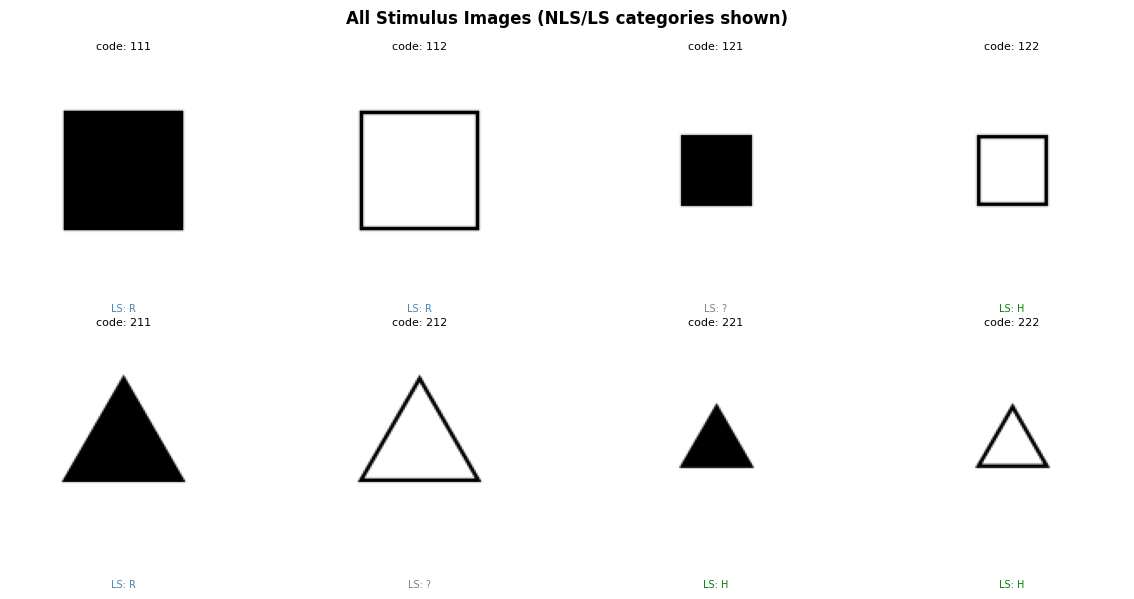

In [89]:
# Preview all 8 stimulus images with NLS categories shown
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, code in zip(axes.flat, ALL_STIM_CODES):
    img_bytes = base64.b64decode(STIMULUS_IMAGES[code])
    img = plt.imread(io.BytesIO(img_bytes), format="png")
    ax.imshow(img); ax.axis("off")
    nls_cat = TRUE_CATEGORIES_NLS.get(code, "?")
    ls_cat  = TRUE_CATEGORIES_LS.get(code,  "?")
    nls_color = "purple" if nls_cat == "Z" else "darkorange" if nls_cat == "W" else "gray"
    ls_color  = "steelblue" if ls_cat == "R" else "green" if ls_cat == "H" else "gray"
    ax.set_title(f"code: {code}", fontsize=8)
    ax.set_xlabel(f"NLS: {nls_cat}", fontsize=7, color=nls_color, labelpad=1)
    ax.text(0.5, -0.12, f"LS: {ls_cat}", ha="center", transform=ax.transAxes, fontsize=7, color=ls_color)
fig.suptitle("All Stimulus Images (NLS/LS categories shown)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("stimulus_preview.png", dpi=120, bbox_inches="tight")
plt.show()

In [90]:
def run_visual_simulation(model, simulator, instruction_text, category_tokens,
                           condition, label_map=None, exception_items=None,
                           test_categories=None):
    """Run one complete visual simulation. Stimuli sent as PNG images.

    Multi-turn structure preserves the full image history so the model sees
    each stimulus in sequence, mirroring the human paradigm.
    Assistant responses are framed as full sentences (not bare single letters)
    to avoid triggering Azure's jailbreak filter on forced single-token outputs.

    test_categories: dict mapping all 8 test stimuli -> true category (for novel items).
                     Falls back to simulator.true_categories if None.
    """
    if label_map is None:
        label_map = {t: t for t in category_tokens}
    if exception_items is None:
        exception_items = []

    inverse_map      = {v: k for k, v in label_map.items()}
    shown_cat_tokens = {label_map[t] for t in category_tokens}
    token_cue        = ' or '.join(sorted(shown_cat_tokens))
    inst             = apply_label_map(instruction_text, label_map)

    messages = [
        {"role": "user",      "content": inst},
        {"role": "assistant", "content": "Understood. I am ready to categorize the objects."},
    ]

    def query_image(img_b64, cue_text, valid_tokens):
        """Append current image + cue to full message history and query."""
        user_content = [
            {"type": "image_url", "image_url": {"url": f"data:image/png;base64,{img_b64}"}},
            {"type": "text",      "text": cue_text},
        ]
        try:
            resp = client.chat.completions.create(
                model=model,
                messages=messages + [{"role": "user", "content": user_content}],
                logprobs=True,
                top_logprobs=5,
            )
            lp = resp.choices[0].logprobs
            if lp and lp.content:
                return sample_from_logprobs(lp.content[0].top_logprobs, valid_tokens)
            return parse_token(resp.choices[0].message.content, valid_tokens)
        except Exception as e:
            print(f"  [error] {e}")
            return np.random.choice(sorted(valid_tokens))

    def query_text(text, valid_tokens):
        """Text-only follow-up (typicality) appended to full message history."""
        try:
            resp = client.chat.completions.create(
                model=model,
                messages=messages + [{"role": "user", "content": text}],
                logprobs=True,
                top_logprobs=5,
            )
            lp = resp.choices[0].logprobs
            if lp and lp.content:
                return sample_from_logprobs(lp.content[0].top_logprobs, valid_tokens)
            return parse_token(resp.choices[0].message.content, valid_tokens)
        except Exception as e:
            print(f"  [error] {e}")
            return np.random.choice(sorted(valid_tokens))

    # ── Training block ──────────────────────────────────────────────────────
    train_results = []
    for trial_num, stimulus in enumerate(tqdm(simulator.train_sequence,
                                              desc=f"{model.split('-')[0]} [vis-train]",
                                              leave=True)):
        img_b64      = STIMULUS_IMAGES[stimulus]
        choice_shown = query_image(
            img_b64,
            f"Which category does this object belong to — {token_cue}?",
            shown_cat_tokens
        )
        choice_orig  = inverse_map.get(choice_shown, choice_shown)
        correct, pts = simulator.feedback(stimulus, choice_orig)

        # Full-sentence assistant response avoids single-letter forced output
        # pattern that triggers Azure's jailbreak filter
        messages.append({"role": "user", "content": [
            {"type": "image_url", "image_url": {"url": f"data:image/png;base64,{img_b64}"}},
            {"type": "text",      "text": f"Which category does this object belong to — {token_cue}?"},
        ]})
        messages.append({"role": "assistant",
                         "content": f"I categorize this object as {choice_shown}."})
        messages.append({"role": "user",
                         "content": f"{'Correct' if correct else 'Incorrect'}. You get {pts} point(s)."})
        messages.append({"role": "assistant",
                         "content": "Understood. I will keep learning from the feedback."})

        train_results.append({
            "trial":        trial_num + 1,
            "stimulus":     stimulus,
            "choice":       choice_orig,
            "true_cat":     simulator.true_categories[stimulus],
            "correct":      correct,
            "is_exception": stimulus in exception_items,
        })

    # ── Test block ──────────────────────────────────────────────────────────
    messages.append({"role": "user",
                     "content": "We are now in the test block. "
                                "Categorize each object and rate its typicality."})
    messages.append({"role": "assistant",
                     "content": "Understood. I am ready for the test block."})
    test_results = []

    for stimulus in tqdm(simulator.test_stimuli,
                         desc=f"{model.split('-')[0]} [vis-test]", leave=True):
        img_b64      = STIMULUS_IMAGES[stimulus]
        choice_shown = query_image(
            img_b64,
            f"Which category does this object belong to — {token_cue}?",
            shown_cat_tokens
        )
        choice_orig  = inverse_map.get(choice_shown, choice_shown)

        typ = query_text(
            f"You categorized this object as {choice_shown}. "
            f"How typical is it for the {choice_shown} category, on a scale from 1 (not at all typical) "
            "to 9 (most typical)? Reply with a single digit.",
            {str(i) for i in range(1, 10)}
        )

        messages.append({"role": "user", "content": [
            {"type": "image_url", "image_url": {"url": f"data:image/png;base64,{img_b64}"}},
            {"type": "text",      "text": f"Which category does this object belong to — {token_cue}?"},
        ]})
        messages.append({"role": "assistant",
                         "content": f"I categorize this object as {choice_shown}."})
        messages.append({"role": "user",
                         "content": f"You categorized this as {choice_shown}. "
                                    f"How typical is it for the {choice_shown} category (1-9)?"})
        messages.append({"role": "assistant",
                         "content": f"I rate the typicality of this object as {typ} out of 9."})

        _test_cats = test_categories if test_categories is not None else simulator.true_categories
        true_cat   = _test_cats.get(stimulus)
        is_correct = (choice_orig == true_cat) if true_cat is not None else None
        test_results.append({
            "stimulus":   stimulus,
            "choice":     choice_orig,
            "typicality": int(typ) if typ.isdigit() else None,
            "true_cat":   true_cat or "?",
            "correct":    is_correct,
            "is_novel":   stimulus not in simulator.train_stimuli,
        })

    block_acc, exc_curve, nonexc_curve = compute_block_curves(
        train_results, len(simulator.train_stimuli), exception_items
    )
    return {
        "model": model, "train": train_results, "test": test_results,
        "block_acc": block_acc, "exception_curve": exc_curve,
        "non_exception_curve": nonexc_curve,
    }


In [91]:
# Run Pipeline 2 for both conditions, N_RUNS seeds, counterbalanced across label maps
# (mirrors Pipeline 1 / cell-10 logic exactly)
#
# visual_results[cond][model] = {
#   "all_block_accs":          shape (n_total_runs, N_REPS)  one row per seed×labelmap
#   "mean_block_acc":          shape (N_REPS,)  averaged over seeds & label maps
#   "se_block_acc":            shape (N_REPS,)  SE across runs
#   "mean_exception_curve":    shape (N_REPS,)  averaged over seeds & label maps
#   "mean_non_exception_curve":shape (N_REPS,)  averaged over seeds & label maps
#   "mean_train_acc":          float            averaged over seeds & label maps
#   "raw_train_acc":           float            standard label map, first seed only
#   "runs":                    list of individual run dicts (seed + lmap_label tagged)
#   "block_acc":               alias for mean_block_acc.tolist()  (backward compat)
#   "train":                   list  from standard-label-map run, first seed
#   "test":                    list  from standard-label-map run, first seed
# }

visual_results = {}

for cond_name, cond_cats in CONDITIONS.items():
    visual_results[cond_name] = {}
    train_stim  = TRAIN_STIMULI_MAP[cond_name]
    cat_tokens  = CATEGORY_TOKENS_MAP[cond_name]
    vis_inst    = VISUAL_INSTRUCTIONS[cond_name]
    exc_items   = EXCEPTION_ITEMS_MAP[cond_name]
    maps        = LABEL_MAPS[cond_name]
    maps_to_use = maps if COUNTERBALANCE else [maps[0]]

    print(f"\n{'#'*60}")
    print(f"# CONDITION (visual): {cond_name}  |  maps: {len(maps_to_use)}  |  runs: {N_RUNS}")
    print(f"{'#'*60}")

    for model in VISION_MODELS:
        all_block_accs, all_exc, all_nonexc = [], [], []
        raw_train_acc = None
        runs_log      = []

        for seed_i, seed in enumerate(SEEDS):
            simulator = CategorizationSimulator(
                cond_cats, train_stim, TEST_STIMULI, n_reps=N_REPS, seed=seed
            )

            for lmap in maps_to_use:
                is_standard = all(lmap[k] == k for k in lmap)
                lmap_label  = "standard" if is_standard else "swapped"
                print(f"\n  {model.split('-')[0]} | seed={seed} | map={lmap_label}")

                res = run_visual_simulation(
                    model, simulator, vis_inst, cat_tokens,
                    cond_name, label_map=lmap, exception_items=exc_items,
                    test_categories=TEST_CATEGORIES_MAP[cond_name]
                )

                all_block_accs.append(res["block_acc"])
                all_exc.append(res["exception_curve"])
                all_nonexc.append(res["non_exception_curve"])

                tr_acc = np.mean([r["correct"] for r in res["train"]])
                print(f"    train_acc={tr_acc:.1%}")

                if is_standard and raw_train_acc is None:
                    raw_train_acc = tr_acc

                runs_log.append({**res, "seed": seed, "lmap_label": lmap_label})

        arr            = np.array(all_block_accs, dtype=float)
        mean_block_acc = np.nanmean(arr, axis=0)
        std_run        = next((r for r in runs_log if r["lmap_label"] == "standard"), runs_log[0])

        visual_results[cond_name][model] = {
            # ── new fields (match text_results structure) ──────────────────
            "all_block_accs":           arr,
            "mean_block_acc":           mean_block_acc,
            "se_block_acc":             np.nanstd(arr, axis=0) / np.sqrt(len(arr)),
            "mean_exception_curve":     np.nanmean(all_exc,   axis=0),
            "mean_non_exception_curve": np.nanmean(all_nonexc, axis=0),
            "mean_train_acc":           float(np.nanmean(arr)),
            "raw_train_acc":            raw_train_acc,
            "runs":                     runs_log,
            # ── backward-compat aliases (used by existing plot cells) ──────
            "block_acc":                mean_block_acc.tolist(),
            "train":                    std_run["train"],
            "test":                     std_run["test"],
        }

        test_acc = np.mean([r["correct"] for r in std_run["test"] if r["correct"] is not None])
        print(f"  Averaged train_acc={visual_results[cond_name][model]['mean_train_acc']:.1%}"
              f"  |  Test (std map, first seed): {test_acc:.1%}")

if not any(visual_results.values()):
    print("No VISION_MODELS configured (QUICK_TEST=True skips visual pipeline).")



############################################################
# CONDITION (visual): NLS  |  maps: 2  |  runs: 1
############################################################

  gpt | seed=2 | map=standard


gpt [vis-test]: 100%|██████████| 8/8 [02:11<00:00, 16.49s/it]


    train_acc=75.0%

  gpt | seed=2 | map=swapped


gpt [vis-test]: 100%|██████████| 8/8 [02:15<00:00, 16.97s/it]


    train_acc=83.3%

  gpt | seed=5 | map=standard


...

gpt [vis-test]: 100%|██████████| 8/8 [02:12<00:00, 16.51s/it]


    train_acc=75.0%

  gpt | seed=3 | map=swapped


gpt [vis-test]: 100%|██████████| 8/8 [02:19<00:00, 17.42s/it]

    train_acc=94.4%
  Averaged train_acc=78.7%  |  Test (std map, first seed): 75.0%



/var/folders/6b/k7k7f9q56j1fy7v94985x3tc0000gn/T/ipykernel_41821/700081308.py:75: RuntimeWarning: Mean of empty slice
  "mean_exception_curve":     np.nanmean(all_exc,   axis=0),


### Pipeline 2 — Visual Results

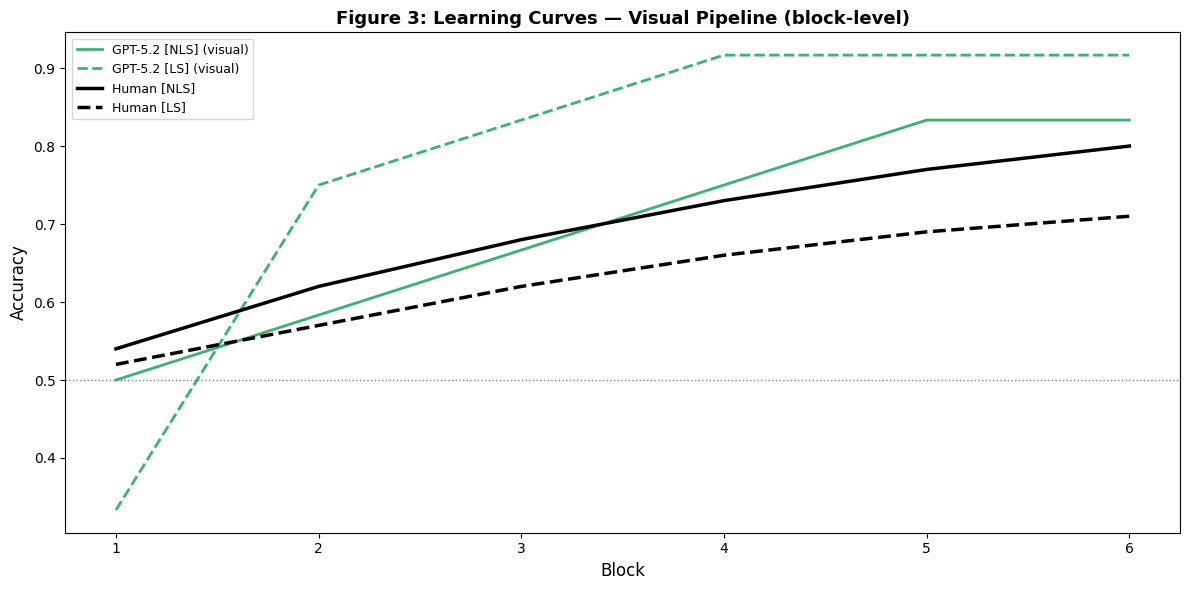

In [20]:
if not any(visual_results.get(c, {}) for c in visual_results):
    print("No visual results to plot (VISION_MODELS empty).")
else:
    # Use MODEL_COLORS for models shared with text pipeline; fallback for VLM-only models
    _VLM_FALLBACK = ["darkorange", "crimson", "forestgreen", "goldenrod"]
    _vis_only = [m for m in VISION_MODELS if m not in MODEL_COLORS]
    VIS_COLORS = {**MODEL_COLORS,
                  **{m: c for m, c in zip(_vis_only, _VLM_FALLBACK)}}

    fig, ax = plt.subplots(figsize=(12, 6))
    for cond_name, cond_res in visual_results.items():
        ls = COND_NLS if cond_name == "NLS" else COND_LS
        for model, res in cond_res.items():
            ba = res["block_acc"]
            se = res.get("se_block_acc", np.zeros(len(ba)))
            color = VIS_COLORS.get(model, "gray")
            ax.plot(BLOCKS[:len(ba)], ba, color=color,
                    linestyle=ls, linewidth=2,
                    label=f"{fmt_model(model)} [{cond_name}] (visual)")
            ax.fill_between(BLOCKS[:len(ba)],
                            np.array(ba) - se[:len(ba)],
                            np.array(ba) + se[:len(ba)],
                            color=color, alpha=0.15)
    # Human benchmarks — same style as Figure 1
    ax.plot(BLOCKS[:len(HUMAN_NLS_BLOCKS[:N_REPS])], HUMAN_NLS_BLOCKS[:N_REPS],
            color="black", linestyle="-", linewidth=2.5, label="Human [NLS]")
    ax.plot(BLOCKS[:len(HUMAN_LS_BLOCKS[:N_REPS])], HUMAN_LS_BLOCKS[:N_REPS],
            color="black", linestyle="--", linewidth=2.5, label="Human [LS]")
    ax.axhline(0.5, color="gray", linestyle=":", linewidth=1)
    ax.set_xlabel("Block", fontsize=12)
    ax.set_ylabel("Accuracy", fontsize=12)
    ax.set_xticks(BLOCKS)
    ax.set_xticklabels([str(b) for b in BLOCKS])
    _all_y3 = list(HUMAN_NLS_BLOCKS[:N_REPS]) + list(HUMAN_LS_BLOCKS[:N_REPS]) + [0.5]
    for _cr in visual_results.values():
        for _r in _cr.values(): _all_y3.extend(_r['block_acc'])
    _lo3, _hi3 = min(_all_y3), max(_all_y3)
    _pad3 = max(0.05 * (_hi3 - _lo3), 0.02)
    ax.set_ylim(_lo3 - _pad3, _hi3 + _pad3)
    ax.set_title("Figure 3: Learning Curves — Visual Pipeline (block-level)",
                 fontsize=13, fontweight="bold")
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig("fig3_visual_learning_curves.png", dpi=150, bbox_inches="tight")
    plt.show()

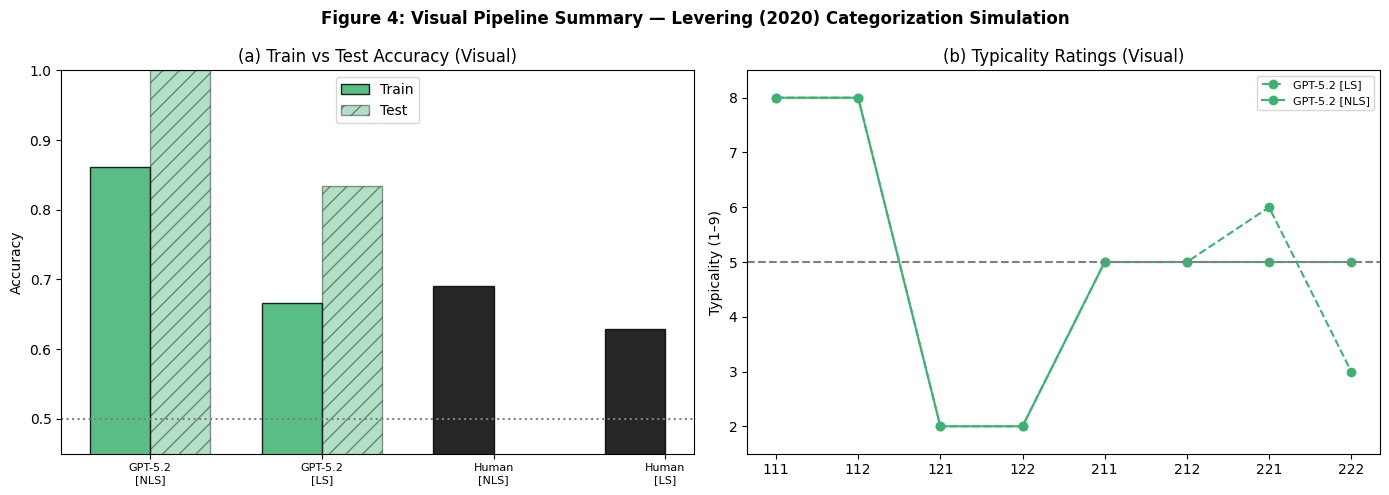

In [17]:
if not any(visual_results.get(c, {}) for c in visual_results):
    print("No visual results to plot.")
else:
    _VLM_FALLBACK = ["darkorange", "crimson", "forestgreen", "goldenrod"]
    _vis_only = [m for m in VISION_MODELS if m not in MODEL_COLORS]
    VIS_COLORS = {**MODEL_COLORS,
                  **{m: c for m, c in zip(_vis_only, _VLM_FALLBACK)}}

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ── Panel (a): Train vs Test accuracy ────────────────────────────────
    ax = axes[0]
    all_labels, train_accs, test_accs, bar_colors = [], [], [], []
    for cond_name, cond_res in visual_results.items():
        for model, res in cond_res.items():
            all_labels.append(f"{fmt_model(model)}\n[{cond_name}]")
            train_accs.append(np.mean([r["correct"] for r in res["train"]]))
            known = [r["correct"] for r in res["test"] if r["correct"] is not None]
            test_accs.append(np.mean(known) if known else np.nan)
            bar_colors.append(VIS_COLORS.get(model, "darkorange"))
    # Human benchmark bars
    all_labels.append("Human\n[NLS]")
    train_accs.append(np.mean(HUMAN_NLS_BLOCKS[:N_REPS]))
    test_accs.append(np.nan)
    bar_colors.append("black")
    all_labels.append("Human\n[LS]")
    train_accs.append(np.mean(HUMAN_LS_BLOCKS[:N_REPS]))
    test_accs.append(np.nan)
    bar_colors.append("black")

    x = np.arange(len(all_labels)); w = 0.35
    ax.bar(x - w/2, train_accs, w, color=bar_colors, alpha=0.85, edgecolor="black", label="Train")
    ax.bar(x + w/2, test_accs,  w, color=bar_colors, alpha=0.4,  edgecolor="black", hatch="//", label="Test")
    ax.set_xticks(x); ax.set_xticklabels(all_labels, fontsize=8)
    _clean_4a = [v for v in train_accs + test_accs if not np.isnan(v)] + [0.5]
    _lo_4a, _hi_4a = min(_clean_4a), max(_clean_4a)
    _pad_4a = max(0.1 * (_hi_4a - _lo_4a), 0.02)
    ax.set_ylim(max(0, _lo_4a - _pad_4a), min(1.0, _hi_4a + _pad_4a))
    ax.axhline(0.5, color="gray", linestyle=":")
    ax.set_ylabel("Accuracy")
    ax.set_title("(a) Train vs Test Accuracy (Visual)")
    ax.legend()

    # ── Panel (b): Typicality ratings ────────────────────────────────────
    ax = axes[1]
    typ_rows = []
    for cond_name, cond_res in visual_results.items():
        for model, res in cond_res.items():
            for r in res["test"]:
                if r["typicality"] is not None:
                    typ_rows.append({"condition": cond_name, "model": model,
                                     "stimulus": r["stimulus"], "typicality": r["typicality"]})
    if typ_rows:
        typ_df = pd.DataFrame(typ_rows)
        COND_STYLE = {"NLS": "-", "LS": "--"}
        for (cond, model), grp in typ_df.groupby(["condition", "model"]):
            ax.plot(grp["stimulus"], grp["typicality"], marker="o",
                    color=VIS_COLORS.get(model, "darkorange"), linewidth=1.5,
                    linestyle=COND_STYLE[cond], label=f"{fmt_model(model)} [{cond}]")
    _typ_vals4 = typ_df['typicality'].dropna().tolist() if typ_rows else [1, 9]
    _lo_4b = max(0, min(_typ_vals4) - 0.5)
    _hi_4b = min(10, max(_typ_vals4) + 0.5)
    ax.set_ylim(_lo_4b, _hi_4b)
    ax.axhline(5, color="gray", linestyle="--")
    ax.set_ylabel("Typicality (1–9)")
    ax.set_title("(b) Typicality Ratings (Visual)")
    ax.legend(fontsize=8)

    plt.suptitle("Figure 4: Visual Pipeline Summary — Levering (2020) Categorization Simulation",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.savefig("fig4_visual_summary.png", dpi=150, bbox_inches="tight")
    plt.show()

In [94]:
# ── Novel vs Trained Test Accuracy ─────────────────────────────────────────
# Tests memorization hypothesis: high trained + low novel = context lookup.
# High novel accuracy = genuine rule generalization.

NOVEL_STIMULI_NLS = {'112', '221'}   # not in NLS training set
NOVEL_STIMULI_LS  = {'121', '212'}   # not in LS training set
NOVEL_STIMULI_MAP = {'NLS': NOVEL_STIMULI_NLS, 'LS': NOVEL_STIMULI_LS}

print('=== Novel vs Trained Test Accuracy (Text Pipeline) ===\n')
for cond_name, cond_res in text_results.items():
    novel_stim = NOVEL_STIMULI_MAP[cond_name]
    for model, res in cond_res.items():
        trained_correct, novel_correct = [], []
        for run in res['runs']:
            for r in run['test']:
                if r['correct'] is None:
                    continue
                if r['stimulus'] in novel_stim:
                    novel_correct.append(r['correct'])
                else:
                    trained_correct.append(r['correct'])
        trained_acc = np.mean(trained_correct) if trained_correct else np.nan
        novel_acc   = np.mean(novel_correct)   if novel_correct   else np.nan
        print(f"{model.split('-')[0]} | {cond_name}:")
        print(f"  Trained: {trained_acc:.1%} (n={len(trained_correct)})")
        print(f"  Novel:   {novel_acc:.1%}   (n={len(novel_correct)})")
        if not np.isnan(novel_acc):
            if novel_acc > 0.6:
                print(f"  → Above chance on novel items: consistent with rule generalization")
            elif novel_acc < 0.4:
                print(f"  → Below chance: possible anti-generalization")
            else:
                print(f"  → Near chance: consistent with memorization hypothesis")
        print()

if any(visual_results.get(c, {}) for c in visual_results):
    print('=== Novel vs Trained Test Accuracy (Visual Pipeline) ===\n')
    for cond_name, cond_res in visual_results.items():
        novel_stim = NOVEL_STIMULI_MAP[cond_name]
        for model, res in cond_res.items():
            trained_correct, novel_correct = [], []
            for run in res['runs']:
                for r in run['test']:
                    if r['correct'] is None:
                        continue
                    if r['stimulus'] in novel_stim:
                        novel_correct.append(r['correct'])
                    else:
                        trained_correct.append(r['correct'])
            trained_acc = np.mean(trained_correct) if trained_correct else np.nan
            novel_acc   = np.mean(novel_correct)   if novel_correct   else np.nan
            print(f"{model.split('-')[0]} [Visual] | {cond_name}:")
            print(f"  Trained: {trained_acc:.1%} (n={len(trained_correct)})")
            print(f"  Novel:   {novel_acc:.1%}   (n={len(novel_correct)})")
            if not np.isnan(novel_acc):
                if novel_acc > 0.6:
                    print(f"  → Above chance on novel items: consistent with rule generalization")
                elif novel_acc < 0.4:
                    print(f"  → Below chance: possible anti-generalization")
                else:
                    print(f"  → Near chance: consistent with memorization hypothesis")
            print()


=== Novel vs Trained Test Accuracy (Text Pipeline) ===

gpt | NLS:
  Trained: 100.0% (n=36)
  Novel:   33.3%   (n=12)
  → Below chance: possible anti-generalization

gpt | LS:
  Trained: 100.0% (n=36)
  Novel:   58.3%   (n=12)
  → Near chance: consistent with memorization hypothesis

=== Novel vs Trained Test Accuracy (Visual Pipeline) ===

gpt [Visual] | NLS:
  Trained: 94.4% (n=36)
  Novel:   0.0%   (n=12)
  → Below chance: possible anti-generalization

gpt [Visual] | LS:
  Trained: 94.4% (n=36)
  Novel:   33.3%   (n=12)
  → Below chance: possible anti-generalization



In [95]:
# ── Novel Stimuli: Per-Guess Breakdown (Text & Visual Pipelines) ────────────
# For each novel stimulus, shows the true category, each model's guess,
# and whether it was correct — aggregated across all runs (standard label map only).

NOVEL_STIMULI_MAP = {'NLS': {'112', '221'}, 'LS': {'121', '212'}}

def novel_stimulus_table(results_dict, pipeline_label):
    rows = []
    for cond_name, cond_res in results_dict.items():
        novel_stim = NOVEL_STIMULI_MAP[cond_name]
        for model, res in cond_res.items():
            # Collect all guesses per stimulus across runs
            per_stim = {}
            for run in res["runs"]:
                if run.get("lmap_label", "standard") != "standard":
                    continue
                for r in run["test"]:
                    if r["stimulus"] not in novel_stim:
                        continue
                    key = (cond_name, r["stimulus"])
                    if key not in per_stim:
                        per_stim[key] = {"true_cat": r["true_cat"], "guesses": []}
                    if r["correct"] is not None:
                        per_stim[key]["guesses"].append((r["choice"], r["correct"]))
            for (cond, stim), info in sorted(per_stim.items()):
                guesses = info["guesses"]
                n_correct = sum(g[1] for g in guesses)
                n_total   = len(guesses)
                guess_counts = {}
                for g, _ in guesses:
                    guess_counts[g] = guess_counts.get(g, 0) + 1
                guess_str = ", ".join(f"{k}×{v}" for k, v in sorted(guess_counts.items(), key=lambda x: -x[1]))
                rows.append({
                    "Pipeline": pipeline_label,
                    "Cond": cond,
                    "Stimulus": stim,
                    "True": info["true_cat"],
                    "Model": model.split("-")[0],
                    "Guesses": guess_str,
                    "Correct": f"{n_correct}/{n_total}",
                    "Acc": n_correct / n_total if n_total else float("nan"),
                })
    return rows

all_rows = []
if text_results:
    all_rows += novel_stimulus_table(text_results, "Text")
if any(visual_results.get(c, {}) for c in visual_results):
    all_rows += novel_stimulus_table(visual_results, "Visual")

if not all_rows:
    print("No data available.")
else:
    df_novel = pd.DataFrame(all_rows)
    print("=== Novel Stimuli — Guess Breakdown by Model & Pipeline ===\n")
    for (pipe, cond), grp in df_novel.groupby(["Pipeline", "Cond"]):
        print(f"[{pipe} | {cond}]  Novel stimuli: {sorted(NOVEL_STIMULI_MAP[cond])}")
        display_cols = ["Stimulus", "True", "Model", "Guesses", "Correct", "Acc"]
        print(grp[display_cols].sort_values(["Stimulus", "Model"]).to_string(index=False))
        print()


=== Novel Stimuli — Guess Breakdown by Model & Pipeline ===

[Text | LS]  Novel stimuli: ['121', '212']
Stimulus True Model Guesses Correct  Acc
     121    R   gpt     H×3     0/3  0.0
     212    H   gpt     H×3     3/3  1.0

[Text | NLS]  Novel stimuli: ['112', '221']
Stimulus True Model  Guesses Correct      Acc
     112    W   gpt W×2, Z×1     2/3 0.666667
     221    Z   gpt      W×3     0/3 0.000000

[Visual | LS]  Novel stimuli: ['121', '212']
Stimulus True Model  Guesses Correct      Acc
     121    R   gpt      H×3     0/3 0.000000
     212    H   gpt R×2, H×1     1/3 0.333333

[Visual | NLS]  Novel stimuli: ['112', '221']
Stimulus True Model Guesses Correct  Acc
     112    W   gpt     Z×3     0/3  0.0
     221    Z   gpt     W×3     0/3  0.0



---
## LS vs NLS Cross-Pipeline Comparison

Aggregated accuracy for text and visual pipelines across both category structures.
- **LS**: shape-majority rule — easy single-dimensional rule
- **NLS**: Levering (2020) multi-dimensional structure — harder, exception items present

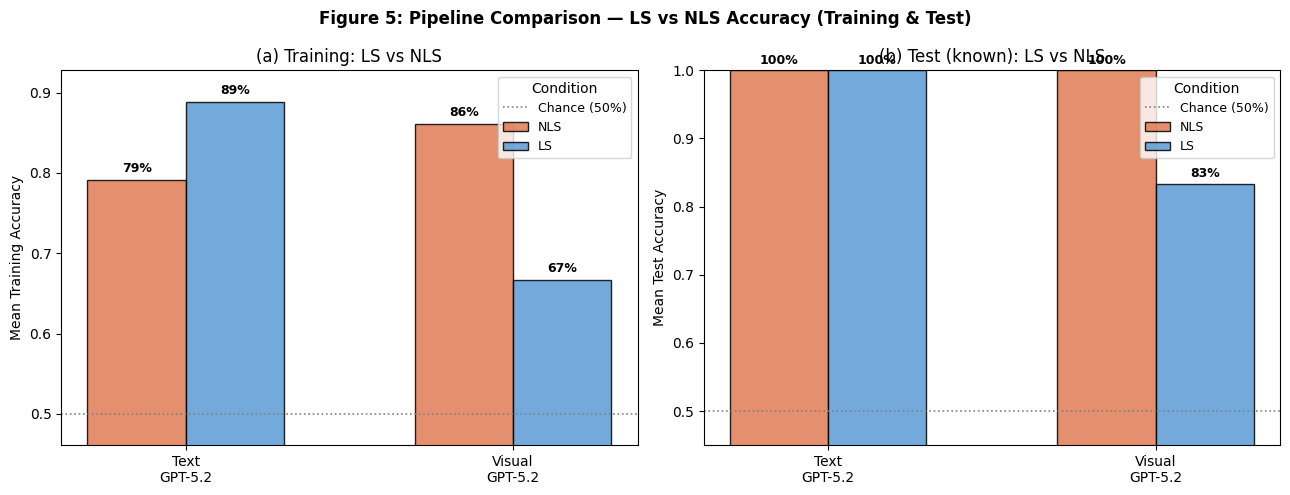

In [23]:
PIPELINE_DATA = []
for pipe_label, results_dict in [("Text", text_results), ("Visual", visual_results)]:
    if not results_dict:
        continue
    for cond_name, cond_res in results_dict.items():
        for model, res in cond_res.items():
            if isinstance(res, dict) and "runs" in res:
                train_acc = res["mean_train_acc"]
                test_known = [r["correct"] for run in res["runs"]
                              for r in run["test"] if r["correct"] is not None]
                test_acc  = np.mean(test_known) if test_known else np.nan
            else:
                train_acc = np.mean([r["correct"] for r in res["train"]])
                known = [r["correct"] for r in res["test"] if r["correct"] is not None]
                test_acc = np.mean(known) if known else np.nan
            PIPELINE_DATA.append({
                "pipeline": pipe_label, "condition": cond_name,
                "model": model,
                "train_acc": train_acc, "test_acc": test_acc,
            })

if not PIPELINE_DATA:
    print("No data to plot.")
else:
    df_all = pd.DataFrame(PIPELINE_DATA)
    pipe_labels = df_all["pipeline"].unique()
    x_pos = np.arange(len(pipe_labels)); bar_width = 0.3
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    def pipe_tick_label(p):
        models_in_pipe = df_all[df_all["pipeline"] == p]["model"].unique()
        model_str = "\n".join(fmt_model(m) for m in sorted(models_in_pipe))
        return f"{p}\n{model_str}"

    tick_labels = [pipe_tick_label(p) for p in pipe_labels]

    for ax_i, acc_col in enumerate(["train_acc", "test_acc"]):
        ax = axes[ax_i]
        for ci, cond in enumerate(["NLS", "LS"]):
            vals = [df_all[(df_all["pipeline"] == p) & (df_all["condition"] == cond)][acc_col].mean()
                    for p in pipe_labels]
            offset = (ci - 0.5) * bar_width
            bars = ax.bar(x_pos + offset, vals, bar_width, label=cond,
                          color=["#e07b54", "#5b9bd5"][ci], alpha=0.85, edgecolor="black")
            for bar, v in zip(bars, vals):
                if not np.isnan(v):
                    ax.text(bar.get_x() + bar.get_width()/2, v + 0.01,
                            f"{v:.0%}", ha="center", fontsize=9, fontweight="bold")
        ax.set_xticks(x_pos); ax.set_xticklabels(tick_labels, fontsize=10)
        _all_v5 = []
        for _cond in ["NLS", "LS"]:
            _all_v5.extend([v for v in
                [df_all[(df_all['pipeline']==p)&(df_all['condition']==_cond)][acc_col].mean()
                 for p in pipe_labels] if not np.isnan(v)])
        _all_v5.append(0.5)
        _lo5, _hi5 = min(_all_v5), max(_all_v5)
        _pad5 = max(0.1 * (_hi5 - _lo5), 0.02)
        ax.set_ylim(max(0, _lo5 - _pad5), min(1.0, _hi5 + _pad5))
        ax.axhline(0.5, linestyle=":", color="gray", linewidth=1.2, label="Chance (50%)")
        if len(pipe_labels) == 1:
            ax.set_xlim(-0.5, 0.5 + len(pipe_labels))
        ax.set_ylabel(f"Mean {'Training' if acc_col == 'train_acc' else 'Test'} Accuracy")
        ax.set_title(f"{'(a)' if acc_col == 'train_acc' else '(b)'} "
                     f"{'Training' if acc_col == 'train_acc' else 'Test (known)'}: LS vs NLS")
        ax.legend(title="Condition", fontsize=9, loc="upper right")

    plt.suptitle("Figure 5: Pipeline Comparison — LS vs NLS Accuracy (Training & Test)",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.savefig("fig5_pipeline_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()

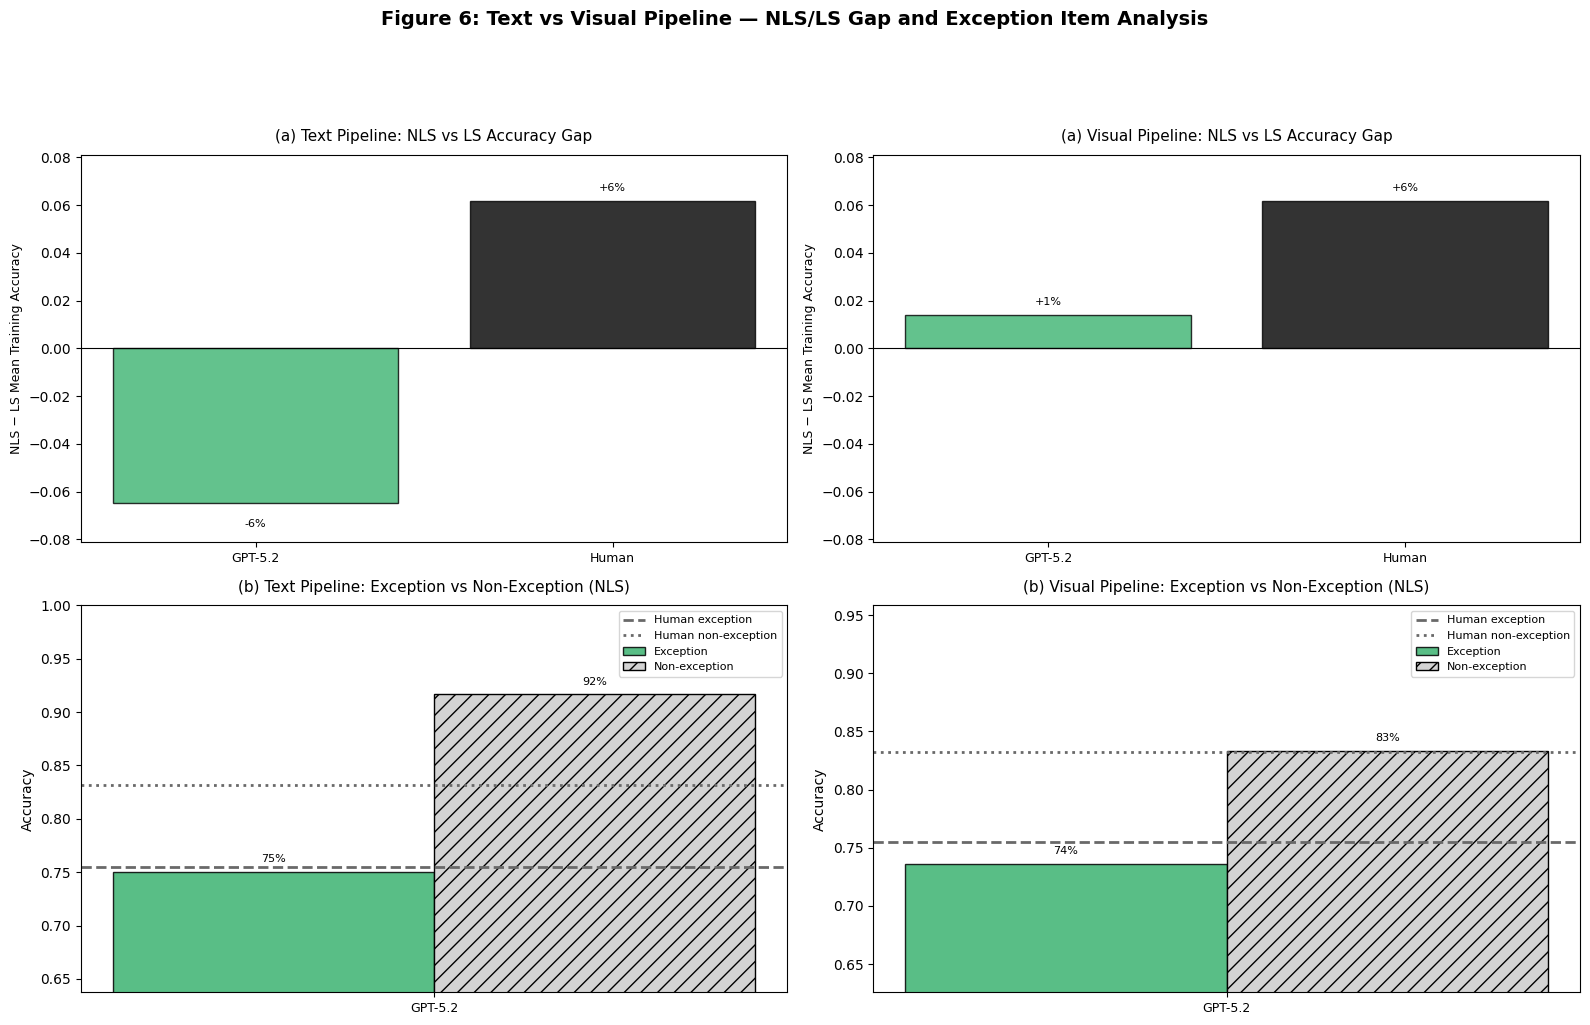

In [97]:
# ── Figure 6 — Text vs Visual: NLS/LS Gap & Exception Item Analysis ─────
_has_text   = bool(text_results)
_has_visual = bool(any(visual_results.get(c, {}) for c in visual_results))

if not _has_text and not _has_visual:
    print("No data to plot.")
else:
    _VLM_FALLBACK = ["darkorange", "crimson", "forestgreen", "goldenrod"]
    _vis_only = [m for m in VISION_MODELS if m not in MODEL_COLORS]
    VIS_COLORS6 = {**MODEL_COLORS, **{m: c for m, c in zip(_vis_only, _VLM_FALLBACK)}}

    all_text_models6 = list(dict.fromkeys(m for cond in text_results.values() for m in cond))
    all_vis_models6  = list(dict.fromkeys(m for cond in visual_results.values() for m in cond))

    human_gap6 = np.mean(HUMAN_NLS_BLOCKS[:N_REPS]) - np.mean(HUMAN_LS_BLOCKS[:N_REPS])

    # ── Panel (a) data: NLS-LS accuracy gap ──────────────────────────────
    gaps_t, labels_t, colors_t = [], [], []
    for model in all_text_models6:
        nls = text_results.get("NLS", {}).get(model, {}).get("mean_train_acc", np.nan)
        ls  = text_results.get("LS",  {}).get(model, {}).get("mean_train_acc", np.nan)
        gaps_t.append(nls - ls)
        labels_t.append(fmt_model(model)); colors_t.append(MODEL_COLORS.get(model, "gray"))
    gaps_t.append(human_gap6); labels_t.append("Human"); colors_t.append("black")

    gaps_v, labels_v, colors_v = [], [], []
    for model in all_vis_models6:
        nls = visual_results.get("NLS", {}).get(model, {}).get("mean_train_acc", np.nan)
        ls  = visual_results.get("LS",  {}).get(model, {}).get("mean_train_acc", np.nan)
        gaps_v.append(nls - ls)
        labels_v.append(fmt_model(model)); colors_v.append(VIS_COLORS6.get(model, "gray"))
    gaps_v.append(human_gap6); labels_v.append("Human"); colors_v.append("black")

    _all_gaps6 = [v for v in gaps_t + gaps_v if not (isinstance(v, float) and np.isnan(v))]
    _max_abs_a = (max(abs(v) for v in _all_gaps6) * 1.25) if _all_gaps6 else 0.15

    # ── Panel (b) data: exception vs non-exception accuracy (NLS) ────────
    # Bug 1 fix: use stored mean_exception_curve (set in cell-17), same as text pipeline
    exc_t, nonexc_t, labels_bt, colors_bt = [], [], [], []
    for model in all_text_models6:
        res = text_results.get("NLS", {}).get(model)
        if res is None: continue
        exc_t.append(np.nanmean(res["mean_exception_curve"]))
        nonexc_t.append(np.nanmean(res["mean_non_exception_curve"]))
        labels_bt.append(fmt_model(model)); colors_bt.append(MODEL_COLORS.get(model, "gray"))

    exc_v, nonexc_v, labels_bv, colors_bv = [], [], [], []
    for model in all_vis_models6:
        res = visual_results.get("NLS", {}).get(model)
        if res is None: continue
        # fall back to exception_curve if mean_exception_curve not yet stored
        _ec = res.get("mean_exception_curve", res.get("exception_curve", [np.nan]))
        _nc = res.get("mean_non_exception_curve", res.get("non_exception_curve", [np.nan]))
        exc_v.append(np.nanmean(_ec))
        nonexc_v.append(np.nanmean(_nc))
        labels_bv.append(fmt_model(model))
        colors_bv.append(VIS_COLORS6.get(model, "gray"))

    # Fix 4: separate y-limits per column so each panel fits its own data
    _all_bt = [v for v in exc_t + nonexc_t + [HUMAN_NLS_EXCEPTION, HUMAN_NLS_NONEXCEPT]
               if not np.isnan(v)]
    _y_min_bt = max(0,   min(_all_bt) * 0.85) if _all_bt else 0
    _y_max_bt = min(1.0, max(_all_bt) * 1.15) if _all_bt else 1.0

    _all_bv = [v for v in exc_v + nonexc_v + [HUMAN_NLS_EXCEPTION, HUMAN_NLS_NONEXCEPT]
               if not np.isnan(v)]
    _y_min_bv = max(0,   min(_all_bv) * 0.85) if _all_bv else 0
    _y_max_bv = min(1.0, max(_all_bv) * 1.15) if _all_bv else 1.0

    # Bug 2 fix: annotation offset uses v directly, not bar_top, for correct negative placement
    def _ann(ax, bars, vals, gap_fmt=False):
        y_range = ax.get_ylim()[1] - ax.get_ylim()[0]
        for bar, v in zip(bars, vals):
            if isinstance(v, float) and np.isnan(v): continue
            offset = y_range * 0.02 if v >= 0 else -y_range * 0.04
            va     = "bottom" if v >= 0 else "top"
            y_pos  = v + offset
            label  = f"{v:+.0%}" if gap_fmt else f"{v:.0%}"
            ax.text(bar.get_x() + bar.get_width()/2, y_pos,
                    label, ha="center", va=va, fontsize=8)

    # ── Figure ────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle(
        "Figure 6: Text vs Visual Pipeline — NLS/LS Gap and Exception Item Analysis",
        fontsize=14, fontweight="bold", y=1.02)

    # axes[0,0]: Panel (a) Text — Bug 3 fix: no axhline(0.5) on gap panels
    ax = axes[0, 0]
    xt   = np.arange(len(gaps_t))
    brs  = ax.bar(xt, gaps_t, color=colors_t, alpha=0.8, edgecolor="black")
    ax.axhline(0, color="black", linestyle="-", linewidth=0.8)
    ax.set_ylim(-_max_abs_a, _max_abs_a)
    ax.set_xticks(xt); ax.set_xticklabels(labels_t, fontsize=9)
    ax.set_ylabel("NLS − LS Mean Training Accuracy", fontsize=9)
    ax.set_title("(a) Text Pipeline: NLS vs LS Accuracy Gap", fontsize=11, pad=10)
    _ann(ax, brs, gaps_t, gap_fmt=True)

    # axes[0,1]: Panel (a) Visual — Bug 3 fix: no axhline(0.5) on gap panels
    ax = axes[0, 1]
    xv   = np.arange(len(gaps_v))
    brs  = ax.bar(xv, gaps_v, color=colors_v, alpha=0.8, edgecolor="black")
    ax.axhline(0, color="black", linestyle="-", linewidth=0.8)
    ax.set_ylim(-_max_abs_a, _max_abs_a)
    ax.set_xticks(xv); ax.set_xticklabels(labels_v, fontsize=9)
    ax.set_ylabel("NLS − LS Mean Training Accuracy", fontsize=9)
    ax.set_title("(a) Visual Pipeline: NLS vs LS Accuracy Gap", fontsize=11, pad=10)
    _ann(ax, brs, gaps_v, gap_fmt=True)

    # axes[1,0]: Panel (b) Text — Fix 4: text-specific y-limits
    ax = axes[1, 0]; w = 0.35
    xbt   = np.arange(len(labels_bt))
    brs_e = ax.bar(xbt - w/2, exc_t,    w, color=colors_bt, alpha=0.85,
                   edgecolor="black", label="Exception")
    brs_n = ax.bar(xbt + w/2, nonexc_t, w, color="lightgray",
                   edgecolor="black", hatch="//", label="Non-exception")
    ax.axhline(HUMAN_NLS_EXCEPTION, color="dimgray", linestyle="--",
               linewidth=2, label="Human exception")
    ax.axhline(HUMAN_NLS_NONEXCEPT, color="dimgray", linestyle=":",
               linewidth=2, label="Human non-exception")
    ax.axhline(0.5, color="gray", linestyle=":", linewidth=1)
    ax.set_ylim(_y_min_bt, _y_max_bt)
    ax.set_xticks(xbt); ax.set_xticklabels(labels_bt, fontsize=9)
    ax.set_ylabel("Accuracy")
    ax.set_title("(b) Text Pipeline: Exception vs Non-Exception (NLS)", fontsize=11, pad=10)
    ax.legend(fontsize=8)
    _ann(ax, brs_e, exc_t); _ann(ax, brs_n, nonexc_t)

    # axes[1,1]: Panel (b) Visual — Fix 4: visual-specific y-limits
    ax = axes[1, 1]
    xbv   = np.arange(len(labels_bv))
    brs_e = ax.bar(xbv - w/2, exc_v,    w, color=colors_bv, alpha=0.85,
                   edgecolor="black", label="Exception")
    brs_n = ax.bar(xbv + w/2, nonexc_v, w, color="lightgray",
                   edgecolor="black", hatch="//", label="Non-exception")
    ax.axhline(HUMAN_NLS_EXCEPTION, color="dimgray", linestyle="--",
               linewidth=2, label="Human exception")
    ax.axhline(HUMAN_NLS_NONEXCEPT, color="dimgray", linestyle=":",
               linewidth=2, label="Human non-exception")
    ax.axhline(0.5, color="gray", linestyle=":", linewidth=1)
    ax.set_ylim(_y_min_bv, _y_max_bv)
    ax.set_xticks(xbv); ax.set_xticklabels(labels_bv, fontsize=9)
    ax.set_ylabel("Accuracy")
    ax.set_title("(b) Visual Pipeline: Exception vs Non-Exception (NLS)", fontsize=11, pad=10)
    ax.legend(fontsize=8)
    _ann(ax, brs_e, exc_v); _ann(ax, brs_n, nonexc_v)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig("fig6_text_vs_visual_panel_ab.png", dpi=150, bbox_inches="tight")
    plt.show()

---
## Typicality Ratings — Human vs Text vs Visual Pipeline

Typicality ratings (1 = not at all typical, 9 = most typical) collected during the test block, compared across three sources:
- **Human** participants (Psych-101 / Levering 2020), averaged over all participants per stimulus per condition
- **Text pipeline** — model's self-reported typicality from numeric-code stimuli (standard label-map run)
- **Visual pipeline** — model's self-reported typicality from PNG image stimuli (standard label-map run)

In [98]:
# ── Extract human typicality ratings from Psych-101 dataset ───────────────
from datasets import load_dataset
import re as _re

_data_psych = load_dataset('marcelbinz/Psych-101')
_df_psych   = _data_psych['train'].to_pandas()
_lev_df     = _df_psych[_df_psych['experiment'].str.contains('levering', case=False, na=False)]

_TYP_PAT = _re.compile(
    r'You see the image (\d{3}), press <<\w+>> and judged the typicality to be <<(\d)>>'
)
_EXP_COND = {
    'levering2020revisiting/exp1.csv': 'NLS',
    'levering2020revisiting/exp2.csv': 'LS',
}

_human_rows = []
for _, row in _lev_df.iterrows():
    cond     = _EXP_COND[row['experiment']]
    text     = row['text']
    test_idx = text.rfind('Test block:')
    if test_idx == -1:
        continue
    for m in _TYP_PAT.finditer(text[test_idx:]):
        _human_rows.append({
            'condition':  cond,
            'stimulus':   m.group(1),
            'typicality': int(m.group(2)),
        })

human_typ_df  = pd.DataFrame(_human_rows)
human_typ_avg = (human_typ_df
                 .groupby(['condition', 'stimulus'])['typicality']
                 .mean()
                 .reset_index()
                 .rename(columns={'typicality': 'mean_typicality'}))

print("Human typicality (participants per cell):")
print(human_typ_df.groupby(['condition', 'stimulus'])['typicality'].count().unstack().to_string())
print()
print("Average typicality per stimulus:")
print(human_typ_avg.to_string(index=False))


Human typicality (participants per cell):
stimulus   111  112  121  122  211  212  221  222
condition                                        
LS         102  102  102  102  102  102  102  102
NLS        126  126  126  126  126  126  126  126

Average typicality per stimulus:
condition stimulus  mean_typicality
       LS      111         6.666667
       LS      112         6.392157
       LS      121         6.294118
       LS      122         6.049020
       LS      211         6.019608
       LS      212         6.490196
       LS      221         5.852941
       LS      222         6.137255
      NLS      111         6.301587
      NLS      112         6.158730
      NLS      121         6.277778
      NLS      122         6.269841
      NLS      211         5.753968
      NLS      212         6.246032
      NLS      221         5.896825
      NLS      222         6.023810


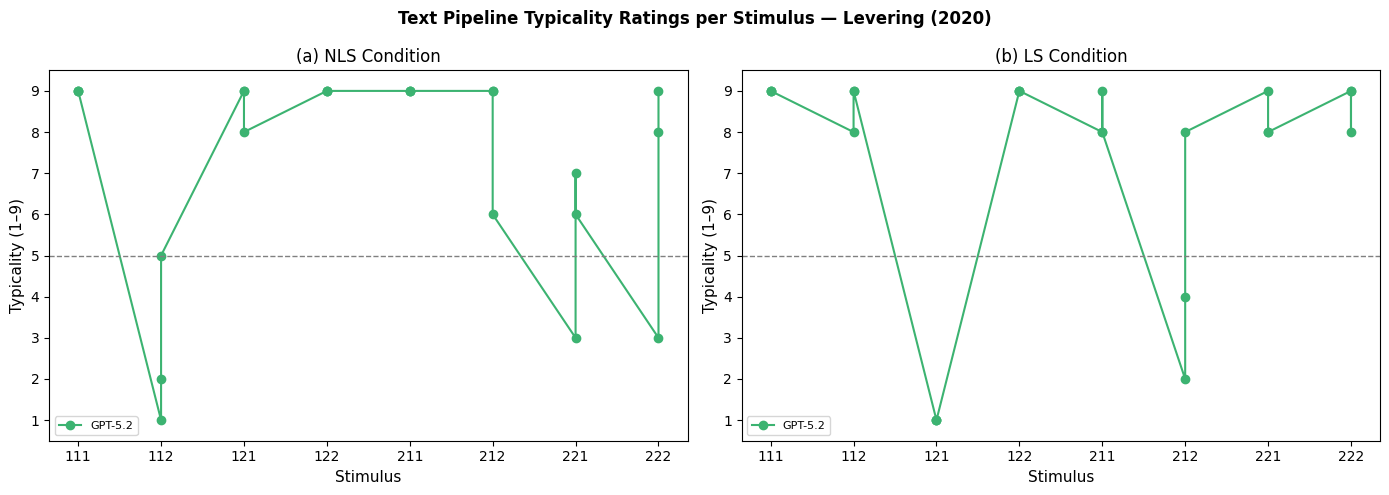

In [99]:
# ── Text Pipeline Typicality — mirrors Figure 4b (visual) ─────────────────
_text_typ_rows = []
for cond_name, cond_res in text_results.items():
    for model, res in cond_res.items():
        for run in res["runs"]:
            if run["lmap_label"] == "standard":
                for r in run["test"]:
                    if r["typicality"] is not None:
                        _text_typ_rows.append({
                            "condition":  cond_name,
                            "model":      model,
                            "stimulus":   r["stimulus"],
                            "typicality": r["typicality"],
                        })

text_typ_df = pd.DataFrame(_text_typ_rows)

if text_typ_df.empty:
    print("No text typicality data found.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ai, cond_name in enumerate(["NLS", "LS"]):
        ax = axes[ai]
        grp_df = text_typ_df[text_typ_df["condition"] == cond_name].sort_values("stimulus")
        for model, grp in grp_df.groupby("model"):
            ax.plot(grp["stimulus"], grp["typicality"], marker="o",
                    color=MODEL_COLORS.get(model, "steelblue"), linewidth=1.5,
                    label=fmt_model(model))
        _typ_vals = grp_df["typicality"].dropna().tolist() or [1, 9]
        ax.set_ylim(max(0, min(_typ_vals) - 0.5), min(10, max(_typ_vals) + 0.5))
        ax.axhline(5, color="gray", linestyle="--", linewidth=1)
        ax.set_xlabel("Stimulus", fontsize=11)
        ax.set_ylabel("Typicality (1–9)", fontsize=11)
        ax.set_title(f"({'ab'[ai]}) {cond_name} Condition", fontsize=12)
        ax.legend(fontsize=8)
    plt.suptitle("Text Pipeline Typicality Ratings per Stimulus — Levering (2020)",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.savefig("fig2b_text_typicality.png", dpi=150, bbox_inches="tight")
    plt.show()


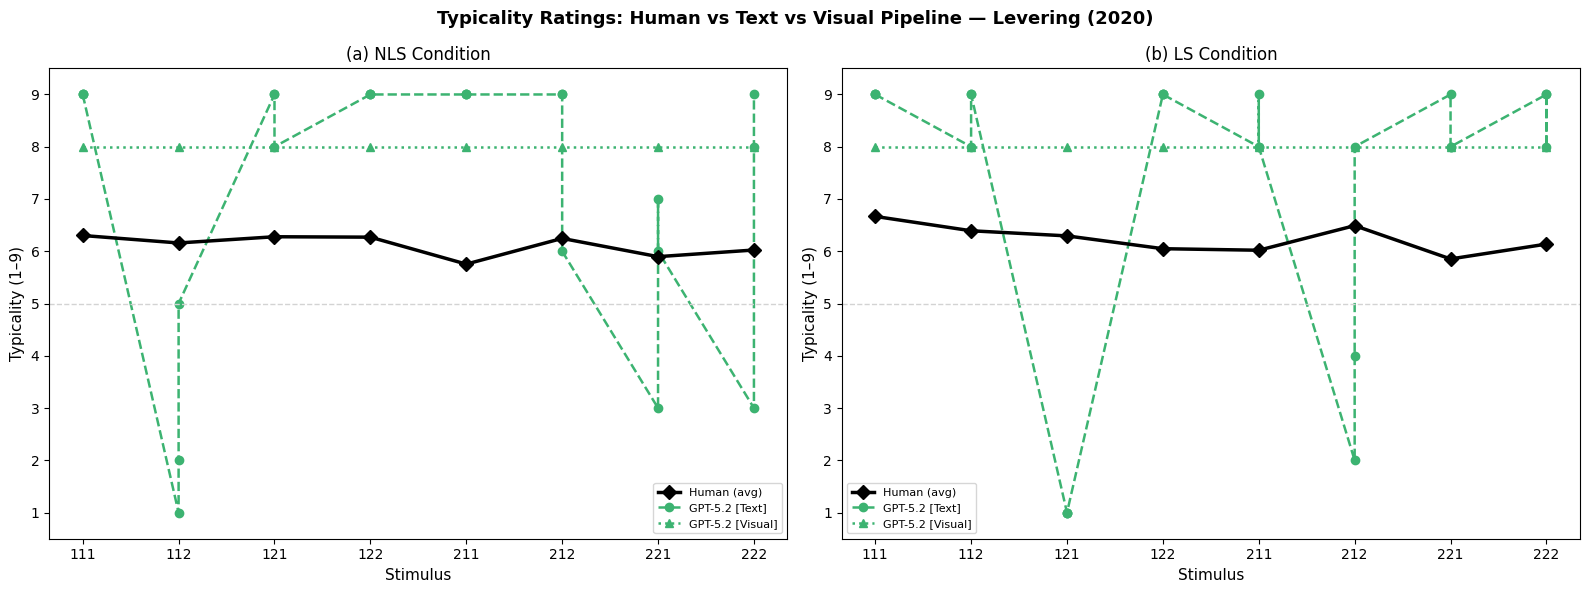

In [100]:
# ── Combined: Human vs Text vs Visual Typicality per Stimulus ─────────────
_has_vis = any(visual_results.get(c, {}) for c in visual_results)
_VLM_FALLBACK_T = ["darkorange", "crimson", "forestgreen", "goldenrod"]
_vis_only_T = [m for m in VISION_MODELS if m not in MODEL_COLORS]
VIS_COLORS_T = {**MODEL_COLORS, **{m: c for m, c in zip(_vis_only_T, _VLM_FALLBACK_T)}}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ai, cond_name in enumerate(["NLS", "LS"]):
    ax = axes[ai]

    # Human — thick black diamond line
    h_grp = human_typ_avg[human_typ_avg["condition"] == cond_name].sort_values("stimulus")
    ax.plot(h_grp["stimulus"], h_grp["mean_typicality"],
            marker="D", color="black", linewidth=2.5, markersize=7,
            label="Human (avg)", zorder=5)

    # Text pipeline — solid lines per model
    if not text_typ_df.empty:
        t_grp = text_typ_df[text_typ_df["condition"] == cond_name].sort_values("stimulus")
        for model, grp in t_grp.groupby("model"):
            ax.plot(grp["stimulus"], grp["typicality"],
                    marker="o", linestyle="--",
                    color=MODEL_COLORS.get(model, "steelblue"), linewidth=1.8,
                    label=f"{fmt_model(model)} [Text]")

    # Visual pipeline — dotted lines per model
    if _has_vis:
        for model, res in visual_results.get(cond_name, {}).items():
            vis_rows = [(r["stimulus"], r["typicality"])
                        for r in res["test"] if r["typicality"] is not None]
            if vis_rows:
                vis_df = (pd.DataFrame(vis_rows, columns=["stimulus", "typicality"])
                          .sort_values("stimulus"))
                ax.plot(vis_df["stimulus"], vis_df["typicality"],
                        marker="^", linestyle=":",
                        color=VIS_COLORS_T.get(model, "darkorange"), linewidth=1.8,
                        label=f"{fmt_model(model)} [Visual]")

    ax.set_ylim(0.5, 9.5)
    ax.axhline(5, color="lightgray", linestyle="--", linewidth=1)
    ax.set_xlabel("Stimulus", fontsize=11)
    ax.set_ylabel("Typicality (1–9)", fontsize=11)
    ax.set_title(f"({'ab'[ai]}) {cond_name} Condition", fontsize=12)
    ax.legend(fontsize=8, loc="best")

plt.suptitle("Typicality Ratings: Human vs Text vs Visual Pipeline — Levering (2020)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_typicality_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


In [101]:
TEST_CATEGORIES_NLS = {
    "111": "Z", "112": "W", "121": "W", "122": "Z",
    "211": "W", "212": "Z", "221": "Z", "222": "W",
}